In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB



# Is VAL disturbance related info routed to Mop and CP

In [3]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [4]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [5]:
df__ = dt.add_pca_df(df_)

In [6]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [13]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'MOp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'SSp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'CP_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'VAL_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# Slice fields
df_tr_sliced = df_tr.copy()
fields = [
    'power',
    'phases', 
    'MOp_rates_pca_concat',
    'SSp_rates_pca_concat',
    'VAL_rates_pca_concat',
    'CP_rates_pca_concat',
    'bhv_concat'
    ]
for field in fields:
    df_tr_sliced[field] = df_tr.apply(
        lambda row: row[field][row["concat_perturb_time"] - 300:row["concat_perturb_time"] + 400, :],
        axis=1
    )

# Add instantaneous phase
df_tr_sliced["perturb_phase"] = df_tr_sliced["phases"].apply(lambda a: a[300, :])

disturbances = np.sum(np.stack(df_tr_sliced.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 17 of 333 rows (5.11%).


## Predict Disturb Score from 

In [8]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [134]:
areas = ['VAL', 'MOp', 'CP', 'SSp']
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)
# test_df = perturb_td.sample(frac=1, random_state=33).reset_index(drop=True)

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
rank = 50
res = {}
for area in areas:
    if area != 'VAL':
        emb = subspaces.compute_embedding(
                    perturb_td__,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=rank)
                )
        arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]
    else:
        arr = np.stack(perturb_td[f'VAL_rates_pca'])[:, 200:, :]
    n_trials, _, _ = arr.shape
    res[area] = cross_val_score(
        Ridge(100),
        arr.reshape(n_trials, -1),
        perturb_td.disturb_sum.values,
        cv=5,
        scoring=vw_r2_scorer
    )
    # print(f'VAL -> {area} r2 mean: {r2s.mean():.3f}, r2 std: {r2s.std():.3f}')



In [132]:
n_trials

100

Text(0.5, 1.0, 'Decoding disturb sum. Rank 50. VAL comm space. 200 trials. Potent')

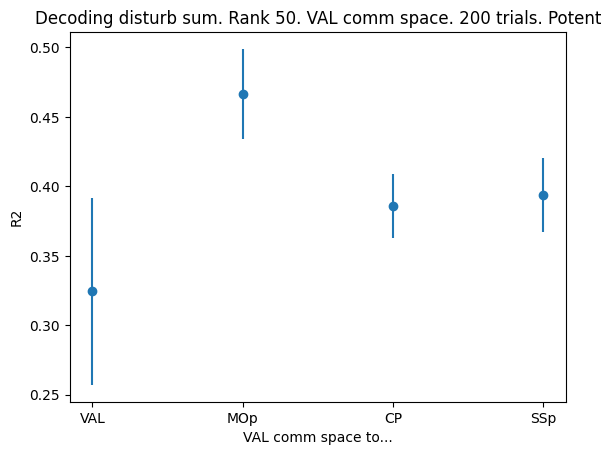

In [135]:
fig, ax = plt.subplots()
ax.errorbar(
    areas, 
    [val.mean() for val in res.values()], 
    yerr=[val.std() for val in res.values()],
    fmt='o')
ax.set_ylabel(f'R2')
ax.set_xlabel(f'VAL comm space to...')
# ax.set_ylim(0, 0.5)

ax.set_title(f'Decoding disturb sum. Rank {rank}. VAL comm space. 200 trials. Potent')

In [11]:
areas = ['VAL', 'MOp', 'CP', 'SSp']
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
rank = 30
res = {}
for area in areas:
    if area != 'VAL':
        emb = subspaces.compute_embedding(
                    perturb_td__,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=rank),
                    null=True
                )
        arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]
    else:
        arr = np.stack(perturb_td[f'VAL_rates_pca'])[:, 200:, :]
    n_trials, _, _ = arr.shape
    res[area] = cross_val_score(
        Ridge(100),
        arr.reshape(n_trials, -1),
        perturb_td.disturb_sum.values,
        cv=5,
        scoring=vw_r2_scorer
    )
    # print(f'VAL -> {area} r2 mean: {r2s.mean():.3f}, r2 std: {r2s.std():.3f}')



Text(0.5, 1.0, 'Decoding disturb sum. Rank 30. VAL comm space. 200 trials. Null')

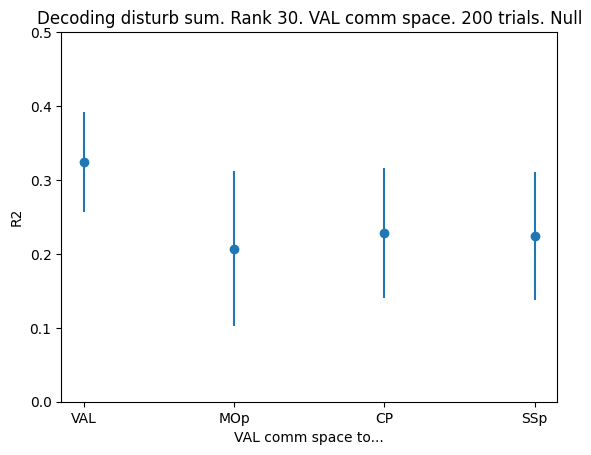

In [12]:
fig, ax = plt.subplots()
ax.errorbar(
    areas, 
    [val.mean() for val in res.values()], 
    yerr=[val.std() for val in res.values()],
    fmt='o')
ax.set_ylabel(f'R2')
ax.set_xlabel(f'VAL comm space to...')
ax.set_ylim(0, 0.5)
ax.set_title(f'Decoding disturb sum. Rank {rank}. VAL comm space. 200 trials. Null')

In [39]:
emb = subspaces.compute_embedding(
            perturb_td,
            f'VAL_rates_pca',
            ['MOp_rates_pca', 'CP_rates_pca'],
            (0, 500),
            subspaces.ReducedRankCommSubspace(rank=50),
            null=False
        )
arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]

n_trials, _, _ = arr.shape
r2s_potent = cross_val_score(
    Ridge(100),
    arr.reshape(n_trials, -1),
    perturb_td.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)
print(f'VAL -> Mop, CP r2 mean: {r2s_potent.mean():.3f}, r2 std: {r2s_potent.std():.3f}')

emb = subspaces.compute_embedding(
            perturb_td,
            f'VAL_rates_pca',
            ['MOp_rates_pca', 'CP_rates_pca'],
            (0, 500),
            subspaces.ReducedRankCommSubspace(rank=30),
            null=True
        )
arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]

n_trials, _, _ = arr.shape
r2s_null = cross_val_score(
    Ridge(100),
    arr.reshape(n_trials, -1),
    perturb_td.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)
print(f'VAL -> Mop, CP Null r2 mean: {r2s_null.mean():.3f}, r2 std: {r2s_null.std():.3f}')


VAL -> Mop, CP r2 mean: 0.219, r2 std: 0.217
VAL -> Mop, CP Null r2 mean: 0.128, r2 std: 0.163


Text(0.5, 1.0, 'Decoding disturb sum. Rank 50. VAL comm space. 200 trials')

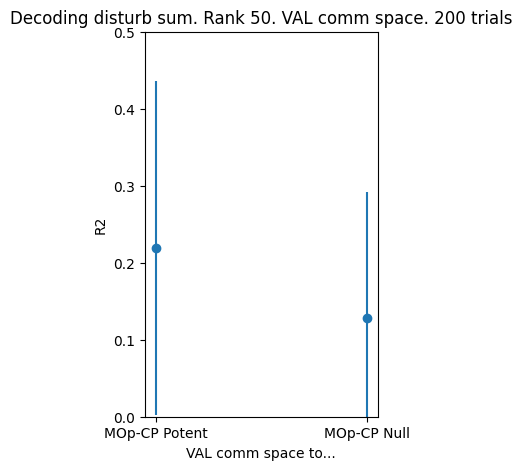

In [40]:
fig, ax = plt.subplots(figsize=(3, 5))
ax.errorbar(
    ['MOp-CP Potent', 'MOp-CP Null'], 
    [r2s_potent.mean(), r2s_null.mean()], 
    yerr=[r2s_potent.std(), r2s_null.std()],
    fmt='o')
ax.set_ylabel(f'R2')
ax.set_xlabel(f'VAL comm space to...')
ax.set_ylim(0, 0.5)
ax.set_title(f'Decoding disturb sum. Rank {rank}. VAL comm space. 200 trials')

## Check explained variances

In [61]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [63]:
area = 'MOp'
rank=30
emb = subspaces.compute_embedding(
                    perturb_td,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=rank)
                )
arr = np.stack(perturb_td[f'VAL_rates_pca'].values)[:, 200:, :]
var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
print(f'Variance in VAL-{area}: {var_} Potent')

area = 'MOp'
emb = subspaces.compute_embedding(
                    perturb_td,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=rank),
                    null=True
                )
arr = np.stack(perturb_td[f'VAL_rates_pca'].values)[:, 200:, :]
var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
print(f'Variance in VAL-{area}: {var_} Null')

Variance in VAL-MOp: 2853.5730064285904 Potent
Variance in VAL-MOp: 16499.19991864492 Null


In [64]:
arr.shape

(100, 301, 168)

In [72]:
val_rank = 7
arr = np.stack(perturb_td[f'VAL_rates_pca'].values)[:, 200:, :val_rank]
var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), np.eye(val_rank))
print(f'Variance in VAL: {var_}')

Variance in VAL: 3288.083400648786


In [53]:
area = 'MOp'
emb = subspaces.compute_embedding(
                    perturb_td,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=50)
                )
arr = np.stack(perturb_td[f'VAL_rates_pca'].values)[:, :, :]
var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
print(f'Variance in VAL-{area}: {var_} Potent')

area = 'MOp'
emb = subspaces.compute_embedding(
                    perturb_td,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=50),
                    null=True
                )
arr = np.stack(perturb_td[f'VAL_rates_pca'].values)[:, :, :]
var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
print(f'Variance in VAL-{area}: {var_} Null')

Variance in VAL-MOp: 4289.872321014969 Potent
Variance in VAL-MOp: 14387.43350751314 Null


## Check potent vs. null for increasing ranks

In [94]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [132]:

areas = ['MOp', 'CP', 'SSp']
area = 'SSp'
ranks = np.arange(10, 100, step=1)
res = {}
for area in areas:
    res[area] = {}
    r2s = []
    vars_ = []
    for rank in tqdm(ranks):
        emb = subspaces.compute_embedding(
                            perturb_td_,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank)
                        )
        arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]
        r2 = cross_val_score(
                Ridge(100),
                arr.reshape(n_trials, -1),
                perturb_td.disturb_sum.values,
                cv=5,
                scoring=vw_r2_scorer
            )
        r2s.append(r2)
        arr = np.stack(perturb_td[f'VAL_rates_pca'].values)
        var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
        vars_.append(var_)

    res[area]['r2s'] = np.array(r2s)
    res[area]['vars'] = np.array(vars_)

100%|██████████| 90/90 [02:12<00:00,  1.47s/it]


In [154]:

areas = ['MOp', 'CP', 'SSp']
area = 'SSp'
ranks = np.arange(10, 100, step=1)
res_null = {}
for area in areas:
    res_null[area] = {}
    r2s = []
    vars_ = []
    for rank in tqdm(ranks):
        emb = subspaces.compute_embedding(
                            perturb_td_,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
        arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]
        r2 = cross_val_score(
                Ridge(100),
                arr.reshape(n_trials, -1),
                perturb_td.disturb_sum.values,
                cv=5,
                scoring=vw_r2_scorer
            )
        r2s.append(r2)
        arr = np.stack(perturb_td[f'VAL_rates_pca'].values)
        var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
        vars_.append(var_)

    res_null[area]['r2s'] = np.array(r2s)
    res_null[area]['vars'] = np.array(vars_)

100%|██████████| 90/90 [02:21<00:00,  1.57s/it]


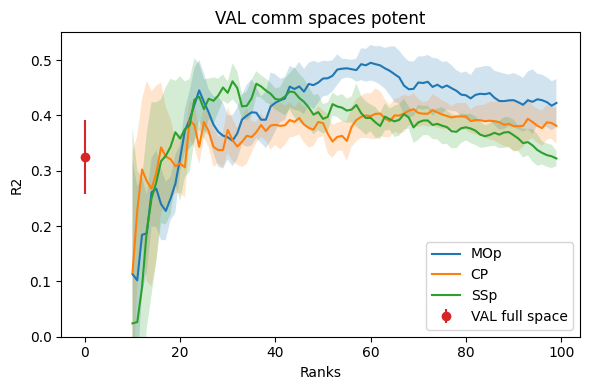

In [155]:
arr = np.stack(perturb_td[f'VAL_rates_pca'])[:, 200:, :]
n_trials, _, _ = arr.shape
r2 = cross_val_score(
    Ridge(100),
    arr.reshape(n_trials, -1),
    perturb_td.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(6, 4))

for area in areas:
    vizutils.shaded_errorbar(ax, ranks, res[area]['r2s'], label=area)

ax.errorbar(0, r2.mean(), yerr=r2.std(), fmt='o', label='VAL full space')
ax.legend()
ax.set_xlabel('Ranks')
ax.set_ylabel('R2')
ax.set_title('VAL comm spaces potent')

ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.show()

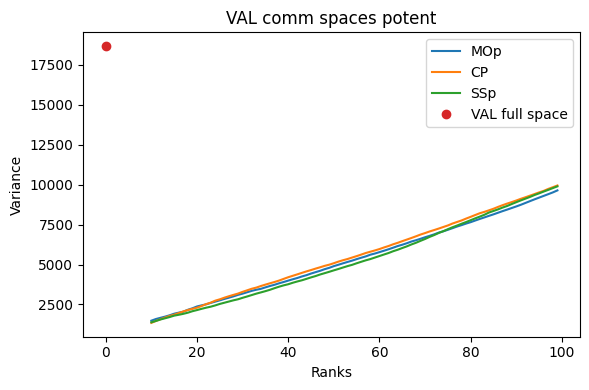

In [161]:
arr = np.stack(perturb_td[f'VAL_rates_pca'])
var_val = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), np.eye(arr.shape[-1]))
# n_trials, _, _ = arr.shape
# r2 = cross_val_score(
#     Ridge(100),
#     arr.reshape(n_trials, -1),
#     perturb_td.disturb_sum.values,
#     cv=5,
#     scoring=vw_r2_scorer
# )

fig, ax = plt.subplots(figsize=(6, 4))

for area in areas:
    ax.plot(ranks, res[area]['vars'], label=area)

ax.errorbar(0, var_val, fmt='o', label='VAL full space')
ax.legend()
ax.set_xlabel('Ranks')
ax.set_ylabel('Variance')
ax.set_title('VAL comm spaces potent')
# ax.set_yscale('log')
# ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.show()

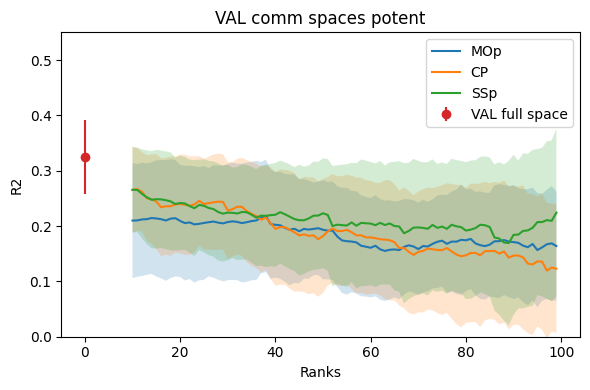

In [162]:
arr = np.stack(perturb_td[f'VAL_rates_pca'])[:, 200:, :]
n_trials, _, _ = arr.shape
r2 = cross_val_score(
    Ridge(100),
    arr.reshape(n_trials, -1),
    perturb_td.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(6, 4))

for area in areas:
    vizutils.shaded_errorbar(ax, ranks, res_null[area]['r2s'], label=area)

ax.errorbar(0, r2.mean(), yerr=r2.std(), fmt='o', label='VAL full space')
ax.legend()
ax.set_xlabel('Ranks')
ax.set_ylabel('R2')
ax.set_title('VAL comm spaces potent')

ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.show()

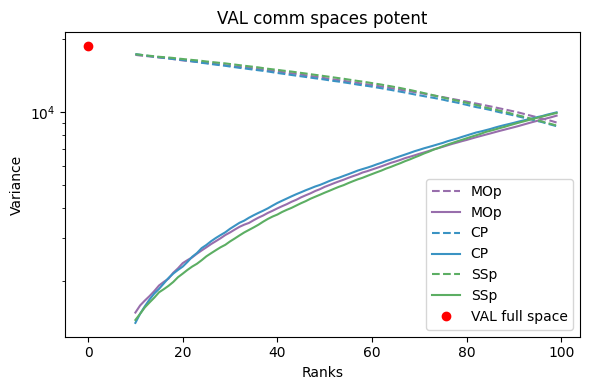

In [172]:
arr = np.stack(perturb_td[f'VAL_rates_pca'])
var_val = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), np.eye(arr.shape[-1]))
# n_trials, _, _ = arr.shape
# r2 = cross_val_score(
#     Ridge(100),
#     arr.reshape(n_trials, -1),
#     perturb_td.disturb_sum.values,
#     cv=5,
#     scoring=vw_r2_scorer
# )

fig, ax = plt.subplots(figsize=(6, 4))

for area in areas:
    ax.plot(ranks, res_null[area]['vars'], label=area, linestyle='--', color=getattr(colors, f'{area}_light'))
    ax.plot(ranks, res[area]['vars'], label=area, color=getattr(colors, f'{area}_light'))

ax.errorbar(0, var_val, fmt='o', label='VAL full space', color='red')
ax.legend()
ax.set_xlabel('Ranks')
ax.set_ylabel('Variance')
ax.set_title('VAL comm spaces potent')
ax.set_yscale('log')
# ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.show()

In [180]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = 0, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = 0, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [173]:
np.concatenate(perturb_td_.VAL_rates_pca.values).shape

(143286, 168)

In [192]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

r2 = cross_val_score(
    Ridge(100),
    np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
    np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :],
    cv=5,
    scoring=vw_r2_scorer
)
print(f'Score {r2.mean()}, std = {r2.std()}')

Score 0.1425518810749054, std = 0.008614224631406426


## Remove MOp from val activity

In [9]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [77]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'MOp'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

118
68
18


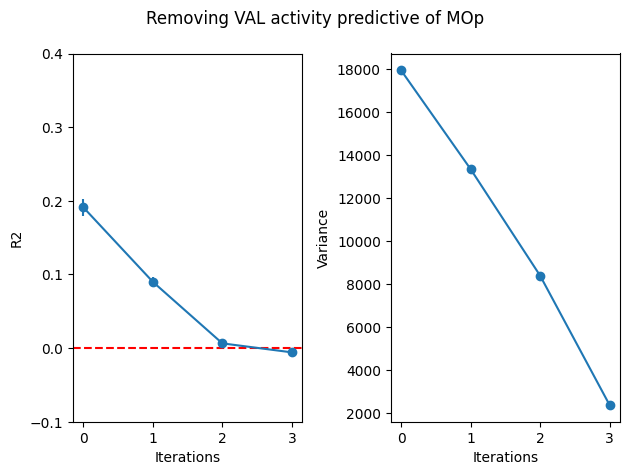

In [90]:
fig, ax = plt.subplots(1, 2)
plt.suptitle('Removing VAL activity predictive of MOp')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()


In [104]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'MOp'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

50


ValueError: 'x' and 'y' must have the same size

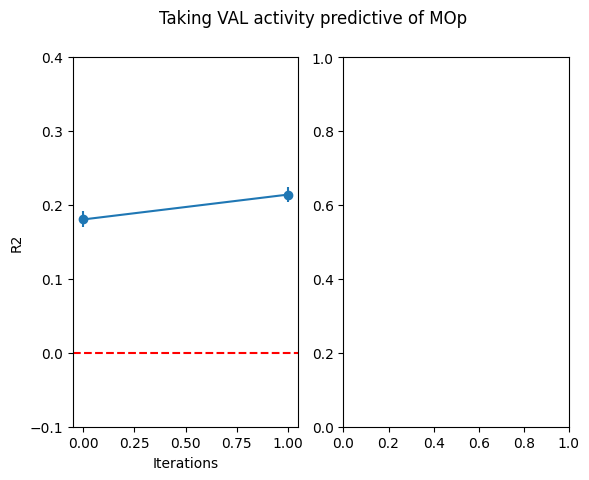

In [143]:
fig, ax = plt.subplots(1, 2)
plt.suptitle('Taking VAL activity predictive of MOp')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()


## Final check - MOp

In [159]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__["val_null_mop"] = perturb_td__["VAL_rates_pca"]
rank = 50 
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_mop',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'val_null_mop', 'val_null_mop')
    dim_val = np.stack(perturb_td__.val_null_mop.values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'val_potent_mop')

118
68


{'mop_potent': 4378.909835706939, 'mop_null': 8494.837885893015}

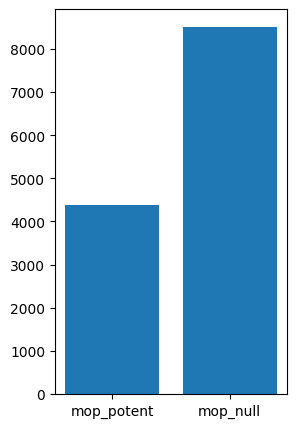

In [160]:
vars_ = {
    'mop_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.val_potent_mop.values),
        np.eye(50)
        ),
    'mop_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.val_null_mop.values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_.keys(), vars_.values())
vars_

In [167]:
perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))



Text(0.5, 1.0, 'Variance in VAL subspaces')

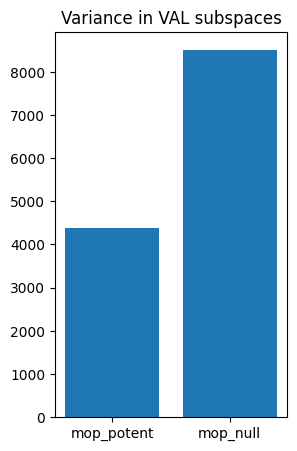

In [175]:
vars_sorted = {
    'mop_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted.val_potent_mop.values),
        np.eye(50)
        ),
    'mop_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted.val_null_mop.values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_.keys(), vars_.values())
ax.set_title('Variance in VAL subspaces')

In [171]:
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_mop'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)
arr_null = np.stack(perturb_td_resorted[f'val_null_mop'])[:, 200:, :]

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

Text(0, 0.5, 'R2')

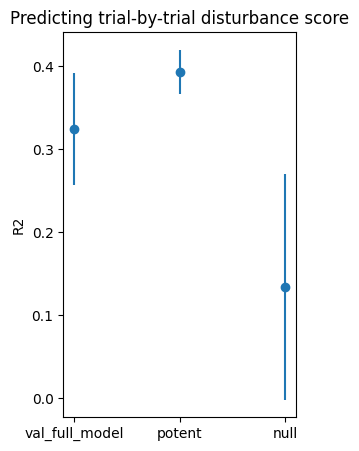

In [174]:
fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')

## Final check - CP

118
68
18
50
118
68


(-0.02, 0.45)

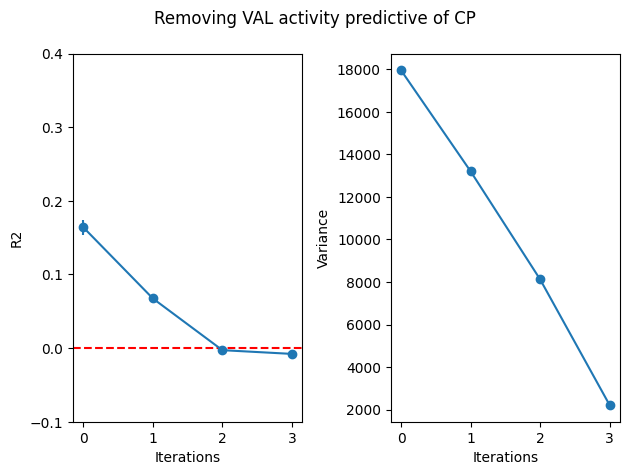

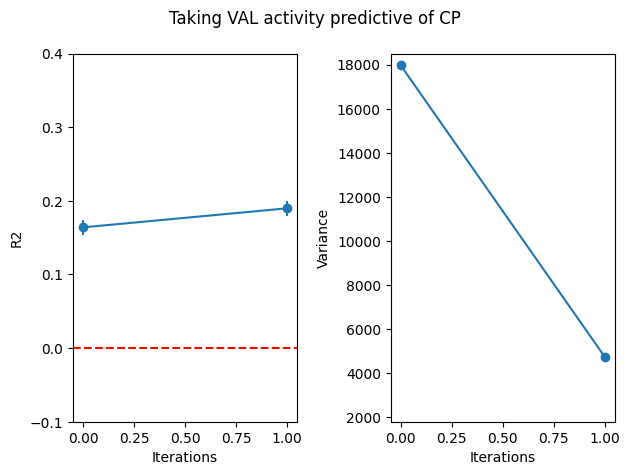

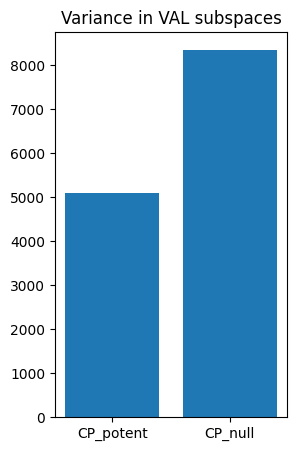

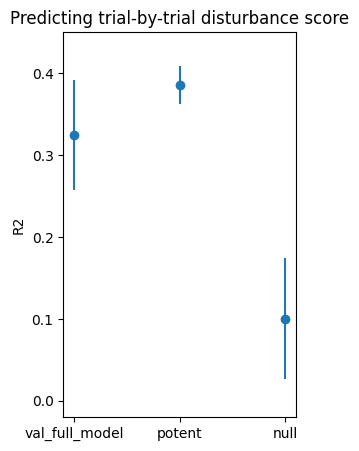

In [202]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'CP'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing VAL activity predictive of {area}')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Taking VAL activity predictive of {area}')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__[f"val_null_{area}"] = perturb_td__["VAL_rates_pca"]
rank = 50 
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_{area}',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, f'val_null_{area}', f'val_null_{area}')
    dim_val = np.stack(perturb_td__[f'val_null_{area}'].values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', f'val_potent_{area}')

perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

vars_sorted = {
    f'{area}_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_potent_{area}'].values),
        np.eye(50)
        ),
    f'{area}_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_null_{area}'].values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_sorted.keys(), vars_sorted.values())
ax.set_title('Variance in VAL subspaces')
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_{area}'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_{area}'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.45)


## Final check - SSp

118
68
18
50
118
68


(-0.02, 0.45)

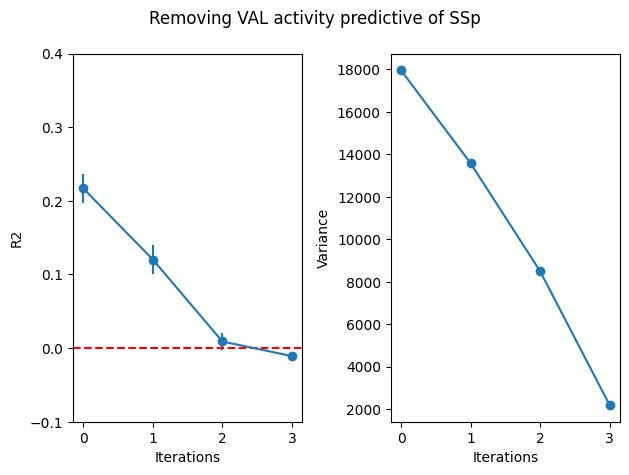

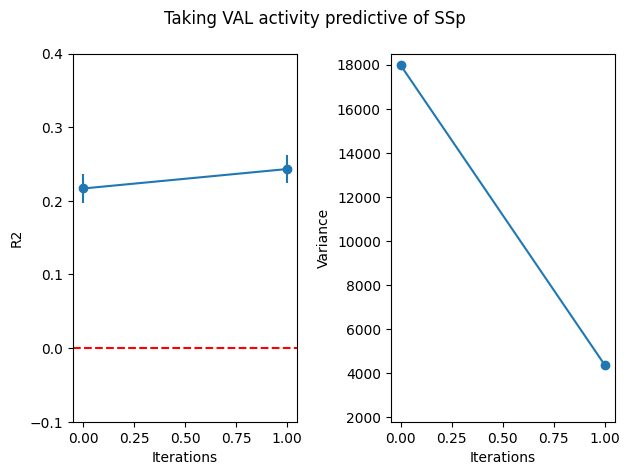

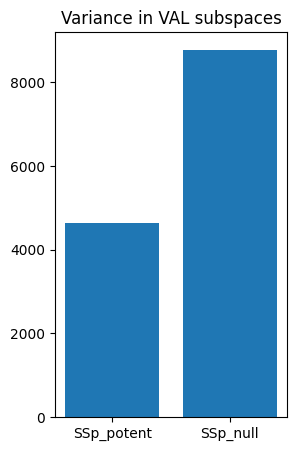

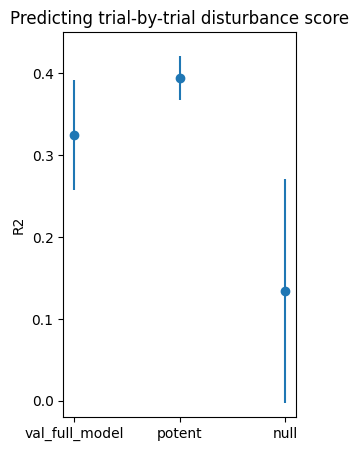

In [200]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'SSp'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing VAL activity predictive of {area}')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Taking VAL activity predictive of {area}')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__[f"val_null_{area}"] = perturb_td__["VAL_rates_pca"]
rank = 50 
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_{area}',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, f'val_null_{area}', f'val_null_{area}')
    dim_val = np.stack(perturb_td__[f'val_null_{area}'].values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', f'val_potent_{area}')

perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

vars_sorted = {
    f'{area}_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_potent_{area}'].values),
        np.eye(50)
        ),
    f'{area}_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_null_{area}'].values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_sorted.keys(), vars_sorted.values())
ax.set_title('Variance in VAL subspaces')
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_{area}'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_{area}'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.45)


## Final check - GPe?

118
68
18
50
118
68


(-0.02, 0.45)

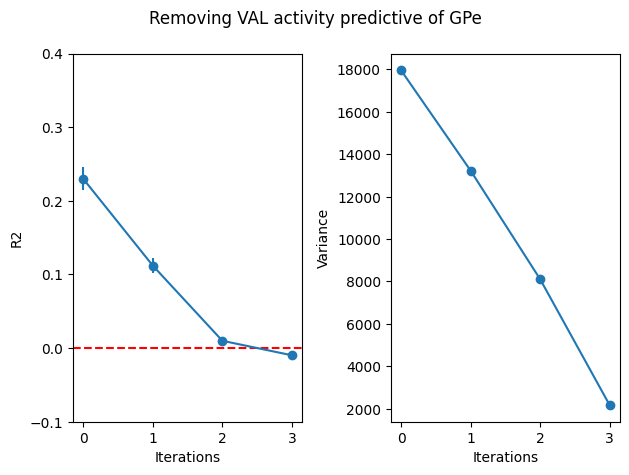

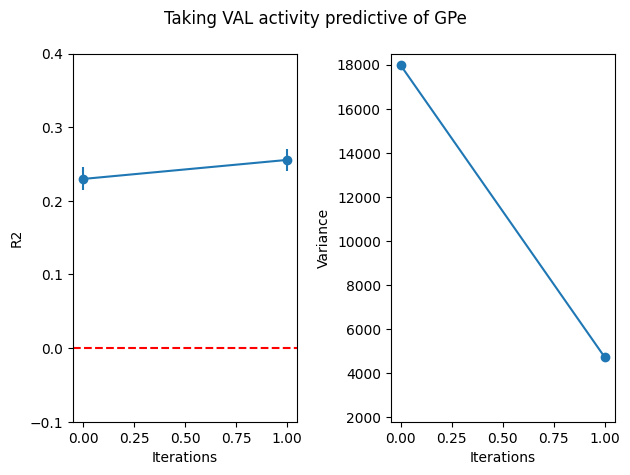

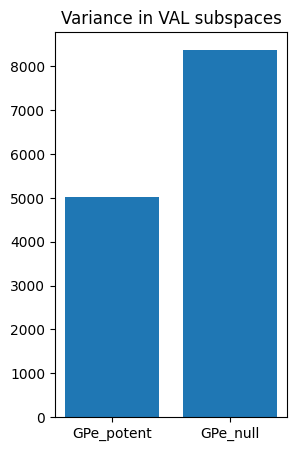

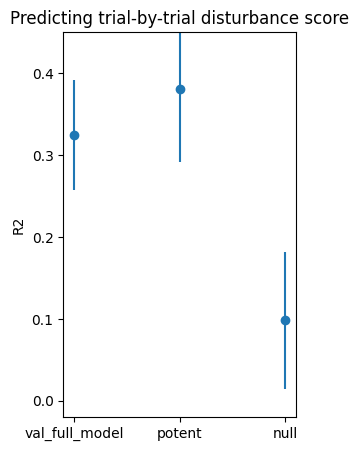

In [11]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
rank = 50
r2s = []
vars_ = []
area = 'GPe'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing VAL activity predictive of {area}')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Taking VAL activity predictive of {area}')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__[f"val_null_{area}"] = perturb_td__["VAL_rates_pca"]
rank = 50 
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_{area}',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, f'val_null_{area}', f'val_null_{area}')
    dim_val = np.stack(perturb_td__[f'val_null_{area}'].values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', f'val_potent_{area}')

perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

vars_sorted = {
    f'{area}_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_potent_{area}'].values),
        np.eye(50)
        ),
    f'{area}_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_null_{area}'].values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_sorted.keys(), vars_sorted.values())
ax.set_title('Variance in VAL subspaces')
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_{area}'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_{area}'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.45)


## Final check mop to VAL?

128
78
28
50
128
78
28


(-0.02, 0.6)

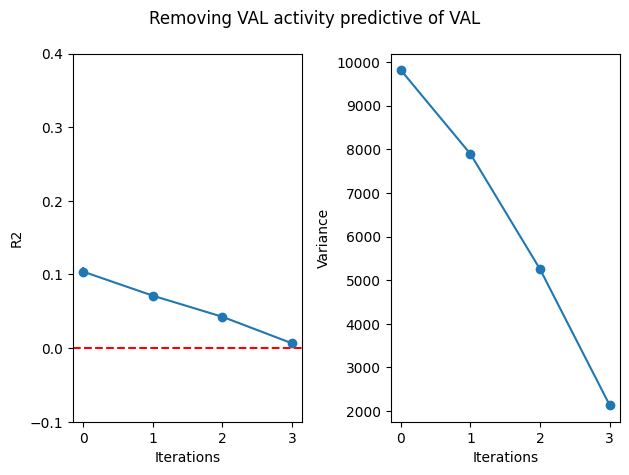

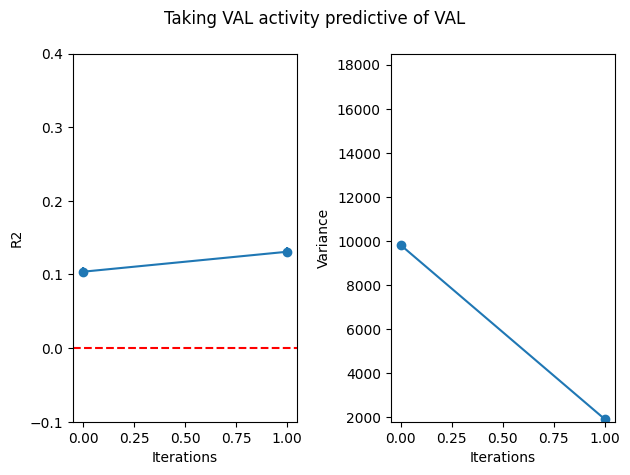

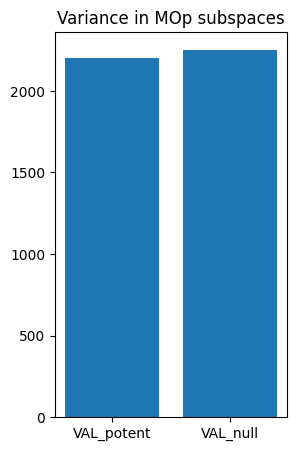

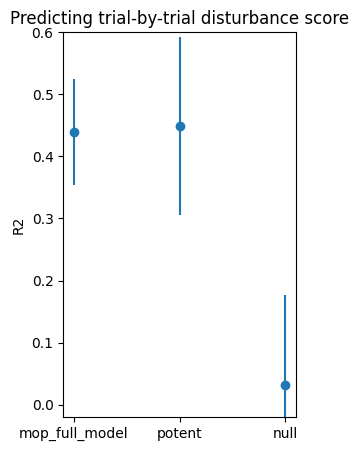

In [17]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.MOp_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'VAL'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.MOp_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'MOp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'MOp_rates_pca', 'MOp_rates_pca')
    dim_val = np.stack(perturb_td__.MOp_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.MOp_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing VAL activity predictive of {area}')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.MOp_rates_pca.values).shape[-1]

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.MOp_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'MOp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'MOp_rates_pca', 'MOp_rates_pca')
    dim_val = np.stack(perturb_td__.MOp_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.MOp_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Taking VAL activity predictive of {area}')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.MOp_rates_pca.values).shape[-1]
perturb_td__[f"val_null_{area}"] = perturb_td__["MOp_rates_pca"]
rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_{area}',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, f'val_null_{area}', f'val_null_{area}')
    dim_val = np.stack(perturb_td__[f'val_null_{area}'].values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'MOp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'MOp_rates_pca', f'val_potent_{area}')

perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

vars_sorted = {
    f'{area}_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_potent_{area}'].values),
        np.eye(50)
        ),
    f'{area}_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_null_{area}'].values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_sorted.keys(), vars_sorted.values())
ax.set_title('Variance in MOp subspaces')
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_{area}'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'MOp_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_{area}'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['mop_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.6)


## FInal check SSp to MOp?

49
29
9
20
49
29
9


(-0.02, 0.6)

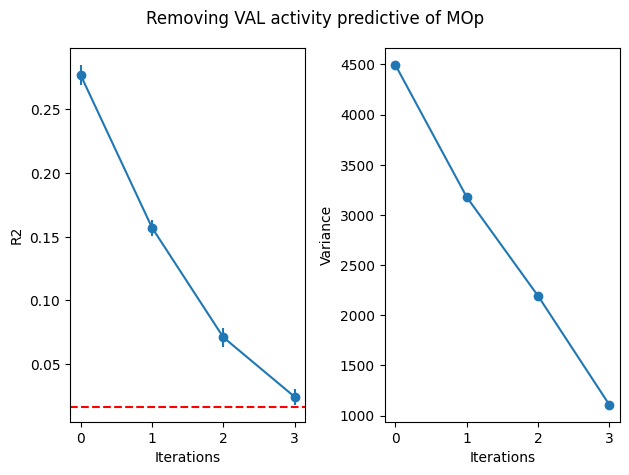

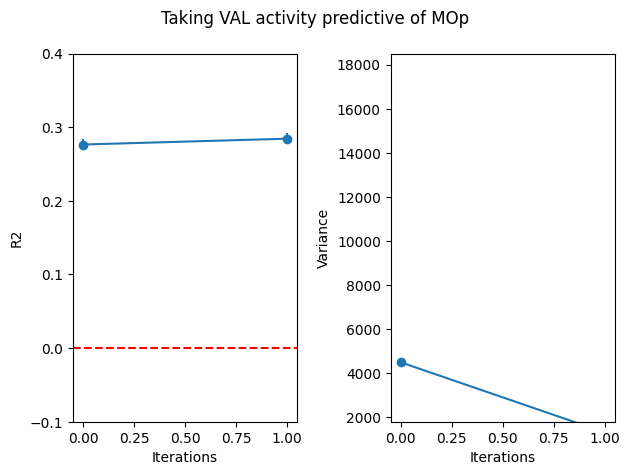

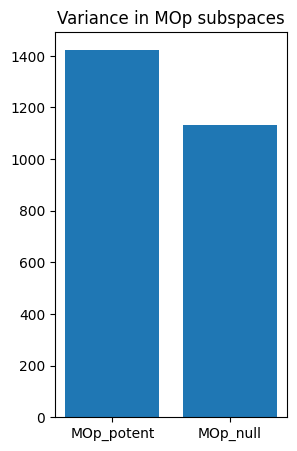

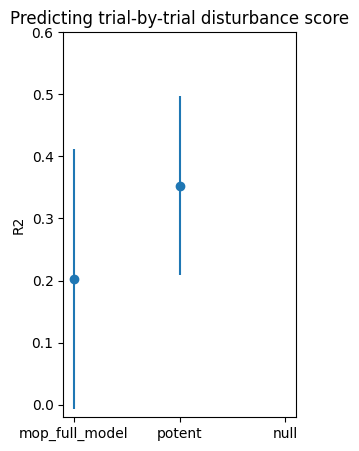

In [32]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)
rank = 20 

dim_val = np.stack(perturb_td__.SSp_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'MOp'
r2_lowerbound = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td_.SSp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.SSp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.SSp_rates_pca.values),
        np.eye(dim_val)
    ))

for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'SSp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'SSp_rates_pca', 'SSp_rates_pca')
    dim_val = np.stack(perturb_td__.SSp_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.SSp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.SSp_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing VAL activity predictive of {area}')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
# ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(r2_lowerbound.mean(), color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.SSp_rates_pca.values).shape[-1]

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.SSp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.SSp_rates_pca.values),
        np.eye(dim_val)
    ))

for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'SSp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'SSp_rates_pca', 'SSp_rates_pca')
    dim_val = np.stack(perturb_td__.SSp_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.SSp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.SSp_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Taking VAL activity predictive of {area}')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.SSp_rates_pca.values).shape[-1]
perturb_td__[f"val_null_{area}"] = perturb_td__["SSp_rates_pca"]
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_{area}',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, f'val_null_{area}', f'val_null_{area}')
    dim_val = np.stack(perturb_td__[f'val_null_{area}'].values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'SSp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'SSp_rates_pca', f'val_potent_{area}')

perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

vars_sorted = {
    f'{area}_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_potent_{area}'].values),
        np.eye(rank)
        ),
    f'{area}_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_null_{area}'].values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_sorted.keys(), vars_sorted.values())
ax.set_title('Variance in MOp subspaces')
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_{area}'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'SSp_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_{area}'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['mop_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.6)


In [23]:
r2_lowerbound.mean()

-0.664115846157074

## Removing between areas?

In [204]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__["val_null_mop"] = perturb_td__["VAL_rates_pca"]
rank = 50 
area = 'MOp'
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_mop',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'val_null_mop', 'val_null_mop')
    dim_val = np.stack(perturb_td__.val_null_mop.values).shape[-1]
    print(dim_val)


118
68


In [211]:
area = 'CP'
dim_val = np.stack(perturb_td__.val_null_mop.values).shape[-1]
r2s = []
vars_ = []
rank = 10 

r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.val_null_mop.values)[:, :],
        np.concatenate(perturb_td__.CP_rates_pca.values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.val_null_mop.values),
        np.eye(dim_val)
    ))

perturb_td__['val_null_mop_cp'] = perturb_td__['val_null_mop']
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_mop_cp',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'val_null_mop_cp', 'val_null_mop_cp')
    dim_val = np.stack(perturb_td__.val_null_mop_cp.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.val_null_mop_cp.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.val_null_mop_cp.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

58


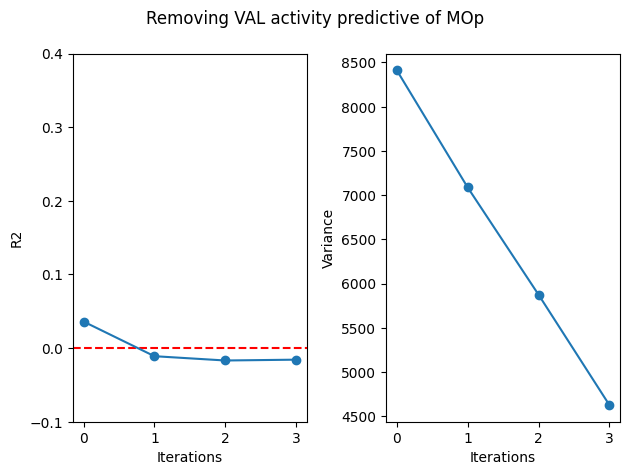

In [210]:
fig, ax = plt.subplots(1, 2)
plt.suptitle('Removing VAL activity predictive of MOp')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()


In [212]:
perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))



(-0.02, 0.45)

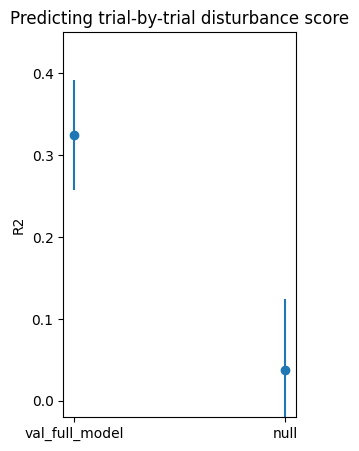

In [217]:
res = {}
# arr_potent = np.stack(perturb_td_resorted[f'val_potent_mop'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_mop_cp'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

# res['potent'] = cross_val_score(
#     Ridge(100),
#     arr_potent.reshape(n_trials, -1),
#     perturb_td_resorted.disturb_sum.values,
#     cv=5,
#     scoring=vw_r2_scorer
# )

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.45)


# Global PCAs??

In [7]:
df__ = dt.add_pca_df(df_, pca_fields = ['VAL_rates'])

In [8]:
df__.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'all_chan_best', 'all_unit_guide',
       'al

In [14]:
df__["all_non_val_rates"] = df__.apply(
    lambda row: np.hstack([row["MOp_rates"], row["CP_rates"], row["SSp_rates"]]),
    axis=1
)

In [17]:
df__ = dt.add_pca_df(df__, pca_fields = ["all_non_val_rates"])

In [20]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# Slice fields
df_tr_sliced = df_tr.copy()

# Add instantaneous phase
disturbances = np.sum(np.stack(df_tr_sliced.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 17 of 333 rows (5.11%).


In [21]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [41]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
rank = 50 

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.all_non_val_rates_pca.values)[:, :rank+100],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'all_non_val_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.all_non_val_rates_pca.values)[:, :rank+100],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

118
68
18


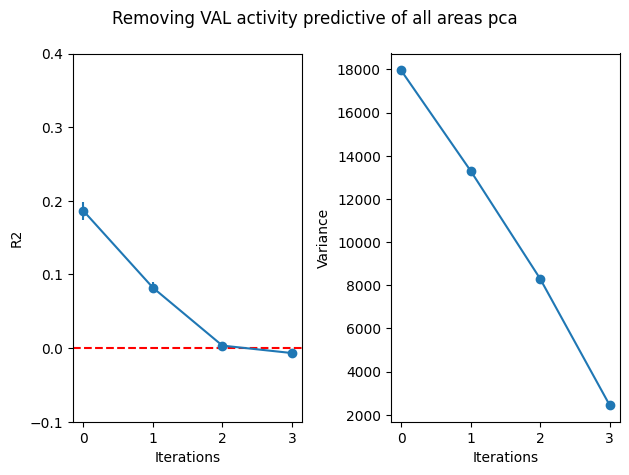

In [42]:
fig, ax = plt.subplots(1, 2)
plt.suptitle('Removing VAL activity predictive of all areas pca')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()


In [46]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__["val_null_all_areas"] = perturb_td__["VAL_rates_pca"]
rank = 50 
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_all_areas',
                            f'all_non_val_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'val_null_all_areas', 'val_null_all_areas')
    dim_val = np.stack(perturb_td__.val_null_all_areas.values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'all_non_val_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'val_potent_all_areas')

118
68


In [51]:
perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))



{'all_areas_potent': 4969.859227861303, 'all_areas_null': 8510.88011753312}

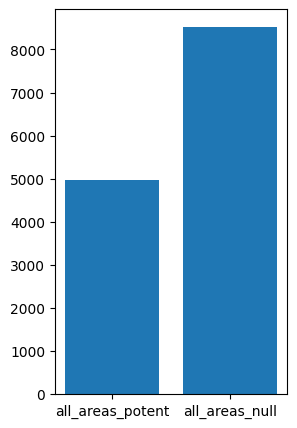

In [52]:
vars_ = {
    'all_areas_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted.val_potent_all_areas.values),
        np.eye(50)
        ),
    'all_areas_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted.val_null_all_areas.values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_.keys(), vars_.values())
vars_

In [53]:
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_all_areas'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_all_areas'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

Text(0, 0.5, 'R2')

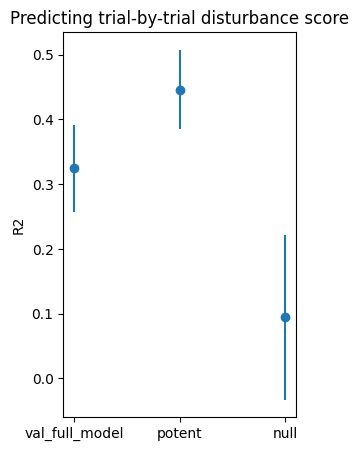

In [54]:
fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')

# Refactored version

In [7]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# Slice fields
df_tr_sliced = df_tr.copy()

# Add instantaneous phase
disturbances = np.sum(np.stack(df_tr_sliced.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 17 of 333 rows (5.11%).


In [163]:
def compute_potent_vs_null(
        td,
        origin_signal,
        target_signal,
        rank,
        target_variable = None,
        window_dec = None,
        scorer = make_scorer(r2_score, multioutput="variance_weighted"),
        window_emb = (0, 500),
        rel_start = -200,
        rel_end = 300,
        n_iter_explore = 3
):
    ###### Restric to interval and shuffle #########
    perturb_td = pyal.restrict_to_interval(td, 'idx_sol_on', rel_start = rel_start, rel_end = rel_end)
    perturb_td = perturb_td.sample(frac=1, random_state=42).reset_index(drop=True)


    #####  Compute r2s and var after privatising  ############
    r2s = []
    vars_ = []
    dim_origin_signal = np.stack(perturb_td[origin_signal].values).shape[-1]

    r2 = cross_val_score(
            Ridge(100),
            np.concatenate(perturb_td[origin_signal].values),
            np.concatenate(perturb_td[target_signal].values)[:, :rank],
            cv=5,
            scoring=scorer
        )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td[origin_signal].values),
        np.eye(dim_origin_signal)
    ))

    for i in range(n_iter_explore):
        emb = subspaces.compute_embedding(
                                perturb_td,
                                origin_signal,
                                target_signal,
                                (window_emb[0], window_emb[-1]),
                                subspaces.ReducedRankCommSubspace(rank=rank),
                                null=True
                            )
        perturb_td = subspaces.project_signal(perturb_td, emb, origin_signal, origin_signal)
        dim_origin_signal = np.stack(perturb_td[origin_signal].values).shape[-1]
        r2 = cross_val_score(
            Ridge(100),
            np.concatenate(perturb_td[origin_signal].values),
            np.concatenate(perturb_td[target_signal].values)[:, :rank],
            cv=5,
            scoring=scorer
        )
        r2s.append(r2)
        vars_.append(subspaces.variance_in_subspace(
            np.concatenate(perturb_td[origin_signal].values),
            np.eye(dim_origin_signal)
        ))
    r2s = np.array(r2s)


    ###### Plot these scores ######
    fig, ax = plt.subplots(1, 2)
    plt.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')
    ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
    ax[0].set_ylim(-0.1, 0.4)
    ax[0].axhline(0, color= 'r', linestyle='dashed')
    ax[0].set_xlabel('Iterations')
    ax[0].set_ylabel('R2')
    ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
    ax[1].set_xlabel('Iterations')
    ax[1].set_ylabel('Variance')

    # ax[1].set_ylim(-0.1, 0.4)
    plt.tight_layout()
    plt.show()

def privatise_and_decode(
    td,
    n_iter,
    origin_signal,
    target_signal,
    rank,
    idx_disturb_to_keep,
    window_emb = (0, 500),
    scorer = make_scorer(r2_score, multioutput="variance_weighted"),
    rel_start = -200,
    rel_end = 300,
    target_var = 'disturb_sum',
    model = Ridge(100),
    window_dec = (200, 300),
    cv=5
):
    td[f'{origin_signal}_null_{target_signal}'] = td[origin_signal]
    td[f'{origin_signal}_potent_{target_signal}'] = td[origin_signal]

    ###### Restric to interval and shuffle #########
    perturb_td = pyal.restrict_to_interval(td, 'idx_sol_on', rel_start = rel_start, rel_end = rel_end)
    perturb_td = perturb_td.sample(frac=1, random_state=42).reset_index(drop=True)

    ##### compute private subspace ######
    for i in range(n_iter):
        emb = subspaces.compute_embedding(
                                perturb_td,
                                f'{origin_signal}_null_{target_signal}',
                                target_signal,
                                (window_emb[0], window_emb[-1]),
                                subspaces.ReducedRankCommSubspace(rank=rank),
                                null=True
                            )
        perturb_td = subspaces.project_signal(perturb_td, emb, 
                                              f'{origin_signal}_null_{target_signal}',
                                              f'{origin_signal}_null_{target_signal}')
        
        dim_null = np.stack(perturb_td[f'{origin_signal}_null_{target_signal}'].values).shape[-1]
    
    ##### compute public subspace ######
    emb = subspaces.compute_embedding(
                            perturb_td,
                            f'{origin_signal}_potent_{target_signal}',
                            target_signal,
                            (window_emb[0], window_emb[-1]),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td = subspaces.project_signal(perturb_td, emb, f'{origin_signal}_potent_{target_signal}', 
                                          f'{origin_signal}_potent_{target_signal}')
    
    ##### Re-sort Compute variances #####
    perturb_td_resorted = perturb_td.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
    perturb_td_resorted = perturb_td_resorted.iloc[idx_disturb_to_keep]
    perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

    vars_sorted = {
        f'{origin_signal}_potent_{target_signal}': subspaces.variance_in_subspace(
            np.concatenate(perturb_td_resorted[f'{origin_signal}_potent_{target_signal}'].values),
            np.eye(rank)
            ),
        f'{origin_signal}_null_{target_signal}': subspaces.variance_in_subspace(
            np.concatenate(perturb_td_resorted[f'{origin_signal}_null_{target_signal}'].values),
            np.eye(dim_null)
            ),
    }
    
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(vars_sorted.keys(), vars_sorted.values())
    ax.set_title(f'Variance in {origin_signal} subspaces')
    plt.show()


    ########### Decode #####################
    res = {}
    arr_full = np.stack(perturb_td_resorted[origin_signal])[:, window_dec[0]:window_dec[1], :]
    arr_potent = np.stack(perturb_td_resorted[f'{origin_signal}_potent_{target_signal}'])[:, window_dec[0]:window_dec[1], :]
    arr_null = np.stack(perturb_td_resorted[f'{origin_signal}_null_{target_signal}'])[:, window_dec[0]:window_dec[1], :]

    n_trials, _, _ = arr_potent.shape


    res['full_model'] = cross_val_score(
        model,
        arr_full.reshape(n_trials, -1),
        perturb_td_resorted[target_var].values.tolist(),
        cv=cv,
        scoring=scorer
    )

    res['potent'] = cross_val_score(
        model,
        arr_potent.reshape(n_trials, -1),
        perturb_td_resorted[target_var].values.tolist(),
        cv=cv,
        scoring=scorer
    )

    res['null'] = cross_val_score(
        model,
        arr_null.reshape(n_trials, -1),
        perturb_td_resorted[target_var].values.tolist(),
        cv=cv,
        scoring=scorer
    )

    
    # X_filt, y_filt, chance = drop_least_populated_class(arr_full.reshape(n_trials, -1), perturb_td_resorted[target_var].values.tolist())
    # X_filt, y_filt, chance = drop_least_populated_class(X_filt, y_filt)

    # res['full_model'] = cross_val_score(
    #     model,
    #     X_filt,
    #     y_filt,
    #     cv=cv,
    #     scoring=scorer
    # )

    # X_filt, y_filt, chance = drop_least_populated_class(arr_potent.reshape(n_trials, -1), perturb_td_resorted[target_var].values.tolist())
    # X_filt, y_filt, chance = drop_least_populated_class(X_filt, y_filt)

    # res['potent'] = cross_val_score(
    #     model,
    #     X_filt,
    #     y_filt,
    #     cv=cv,
    #     scoring=scorer
    # )

    # X_filt, y_filt, chance = drop_least_populated_class(arr_null.reshape(n_trials, -1), perturb_td_resorted[target_var].values.tolist())
    # X_filt, y_filt, chance = drop_least_populated_class(X_filt, y_filt)

    # res['null'] = cross_val_score(
    #     model,
    #     X_filt,
    #     y_filt,
    #     cv=cv,
    #     scoring=scorer
    # )

    fig, ax = plt.subplots(figsize=(3, 5))
    ax.set_title(f'Predicting trial-by-trial {target_var}')
    ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
    ax.set_ylabel('R2')
    # ax.axhline(chance, color='r', linestyle='dashed')
    # ax.set_ylim(-0.02, 0.55)
    plt.show()


def drop_least_populated_class(X, y, *, return_mask=False):
    """
    Drop all samples belonging to the least-populated class in y.

    Parameters
    ----------
    X : array-like, shape (n_samples, ...)  (e.g., your arr_full.reshape(n_trials, -1))
    y : array-like, shape (n_samples,)
    return_mask : bool
        If True, also return the boolean mask used to keep samples.

    Returns
    -------
    X_kept, y_kept  (and mask if return_mask=True)
    """
    X = np.asarray(X)
    y = np.asarray(y)

    if X.shape[0] != y.shape[0]:
        raise ValueError(f"X and y must have same number of samples. Got {X.shape[0]} and {y.shape[0]}.")

    classes, counts = np.unique(y, return_counts=True)
    

    if classes.size < 2:
        # Nothing sensible to drop if only one class
        mask = np.ones_like(y, dtype=bool)
        return (X, y, mask) if return_mask else (X, y)

    least_class = classes[np.argmin(counts)]
    print(f'Min class: {least_class}, counts: {np.min(counts)}')
    mask = (y != least_class)

    X_kept = X[mask]
    y_kept = y[mask]

    return (X_kept, y_kept, mask, 1/len(classes)) if return_mask else (X_kept, y_kept, 1/len(classes))


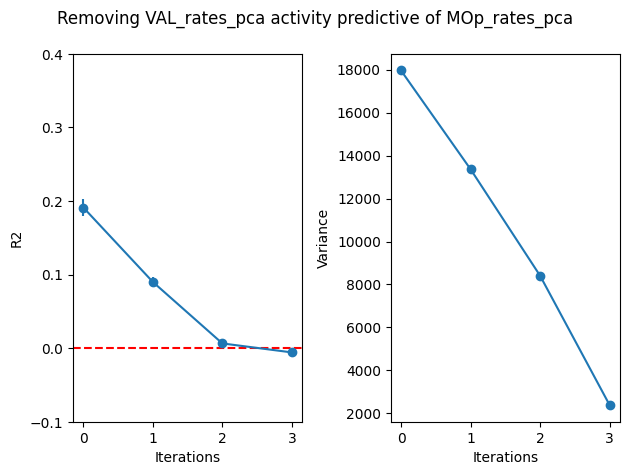

In [15]:
compute_potent_vs_null(
    df_tr_sliced,
    origin_signal='VAL_rates_pca',
    target_signal='MOp_rates_pca',
    rank=50
    )

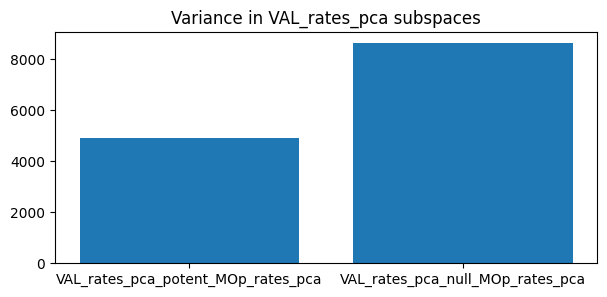

Min class: 0, counts: 2
Min class: 4, counts: 2
Min class: 0, counts: 2
Min class: 4, counts: 2
Min class: 0, counts: 2
Min class: 4, counts: 2


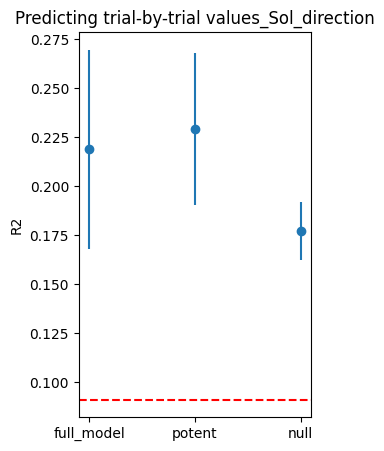

In [126]:
privatise_and_decode(
    df_tr_sliced,
    n_iter = 2,
    origin_signal='VAL_rates_pca',
    target_signal='MOp_rates_pca',
    rank=50,
    idx_disturb_to_keep = sorted(dstrb_idx[:100]),
    target_var = 'values_Sol_direction',
    model = GaussianNB(),
    window_dec=(200, 500),
    scorer='accuracy',
    cv=StratifiedKFold(n_splits=3, shuffle=False)
    )

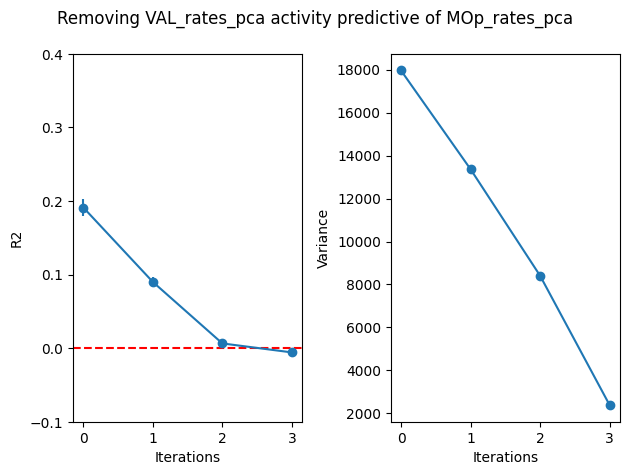

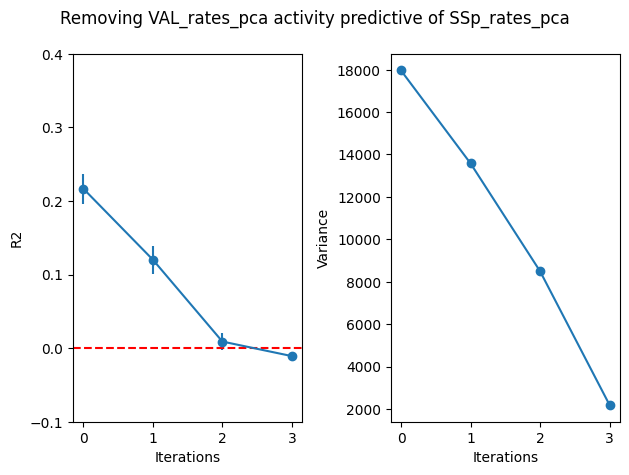

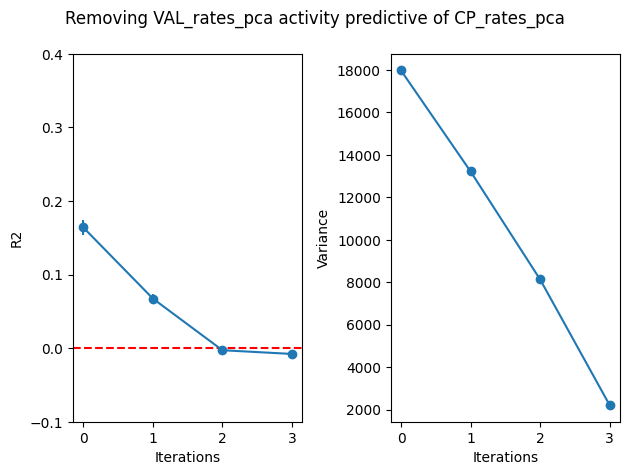

In [127]:
for area in ['MOp', 'SSp', 'CP']:
    compute_potent_vs_null(
        df_tr_sliced,
        origin_signal='VAL_rates_pca',
        target_signal=f'{area}_rates_pca',
        rank=50
    )

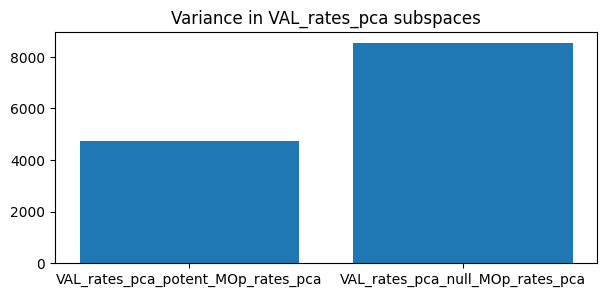

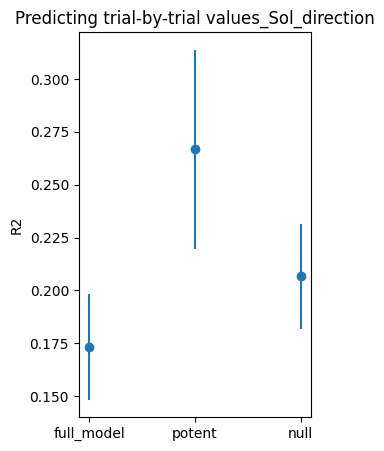

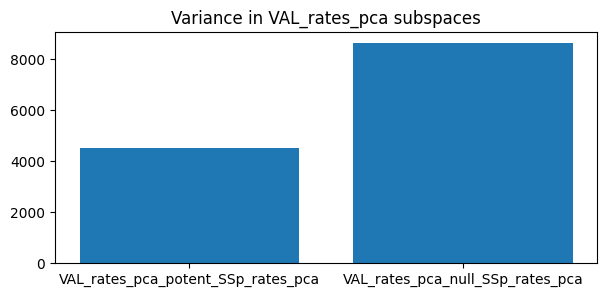

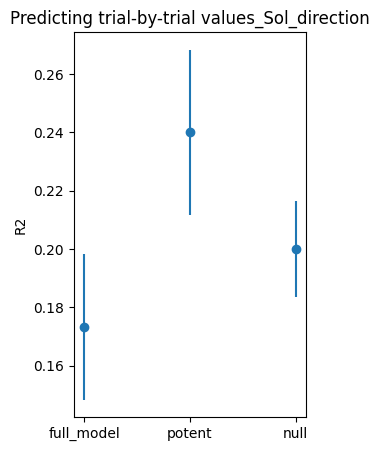

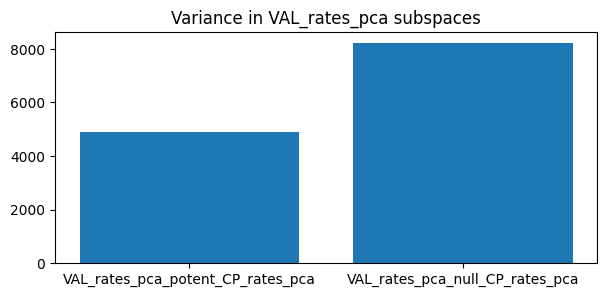

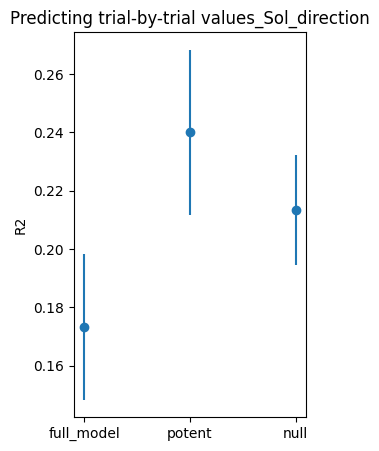

In [165]:
for area in ['MOp', 'SSp', 'CP']:
    privatise_and_decode(
        df_tr_sliced,
        n_iter = 2,
        origin_signal='VAL_rates_pca',
        target_signal=f'{area}_rates_pca',
        rank=50,
        idx_disturb_to_keep = sorted(dstrb_idx[:150]),
        target_var = 'values_Sol_direction',
        model = GaussianNB(),
        window_emb=(0, 500),
        window_dec=(200, 500),
        scorer='accuracy',
        cv=StratifiedKFold(n_splits=3, shuffle=False)
    )

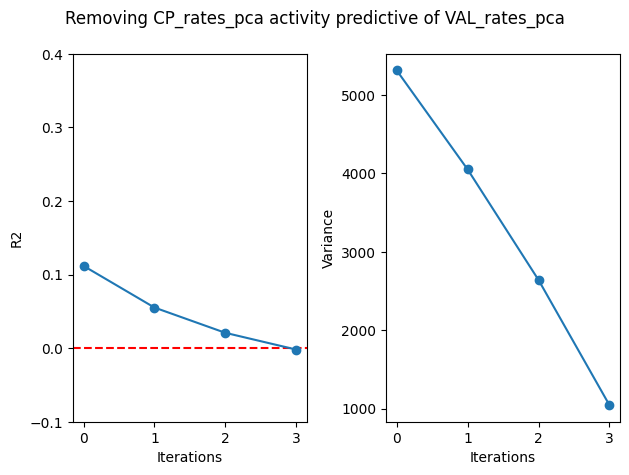

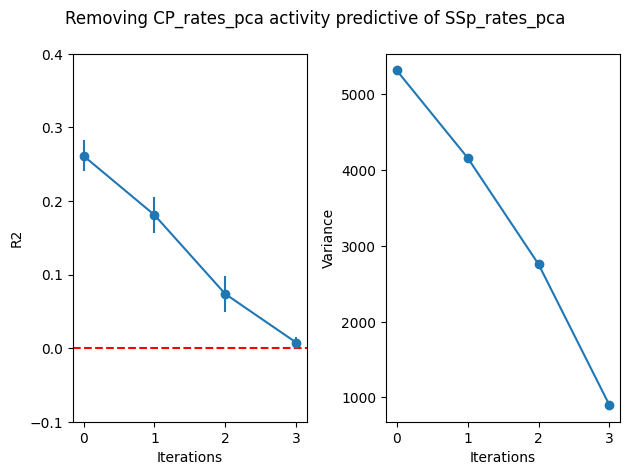

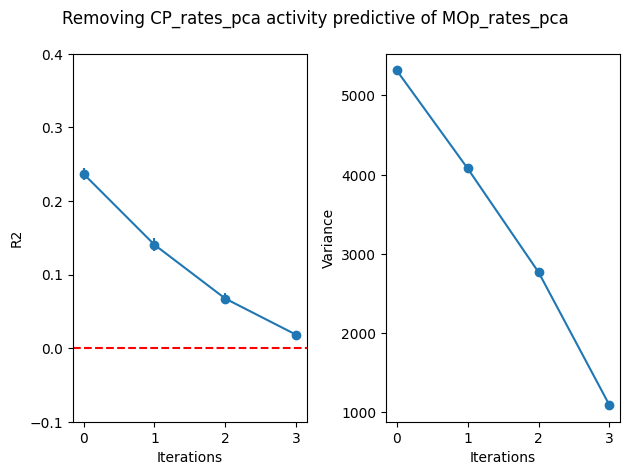

In [151]:
for area in ['VAL', 'SSp', 'MOp']:
    compute_potent_vs_null(
        df_tr_sliced,
        origin_signal='CP_rates_pca',
        target_signal=f'{area}_rates_pca',
        rank=50
    )

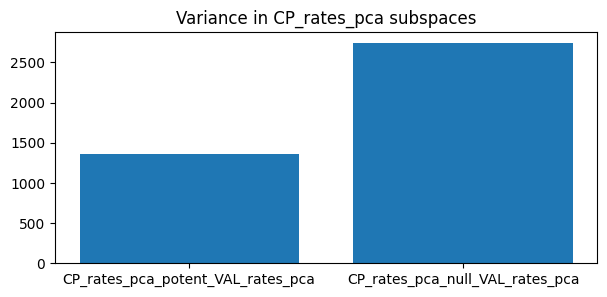

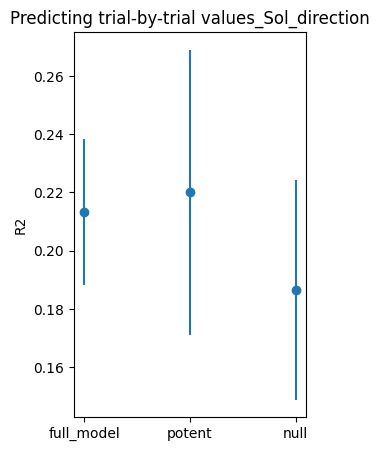

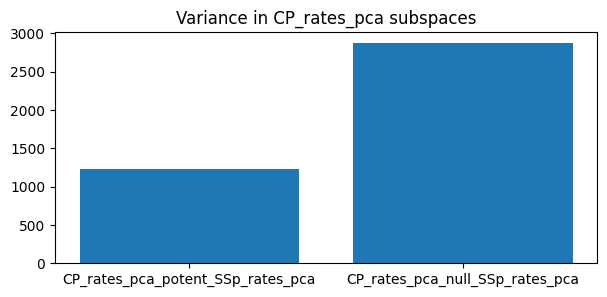

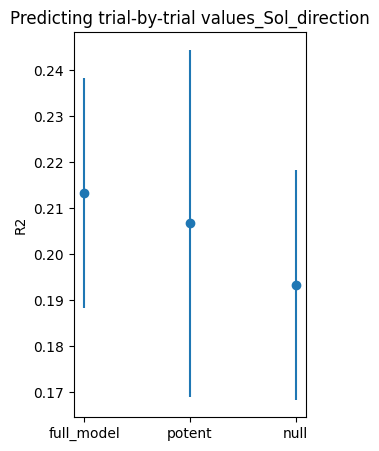

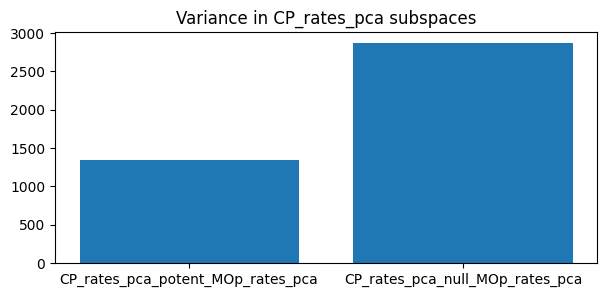

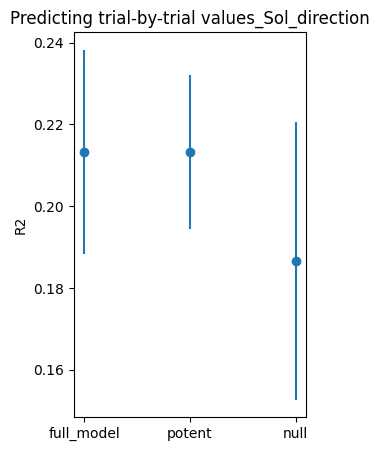

In [166]:
for area in ['VAL', 'SSp', 'MOp']:
    privatise_and_decode(
        df_tr_sliced,
        n_iter = 2,
        origin_signal='CP_rates_pca',
        target_signal=f'{area}_rates_pca',
        rank=50,
        idx_disturb_to_keep = sorted(dstrb_idx[:150]),
        target_var = 'values_Sol_direction',
        model = GaussianNB(),
        window_dec=(200, 500),
        scorer='accuracy',
        cv=StratifiedKFold(n_splits=3, shuffle=False)
    )

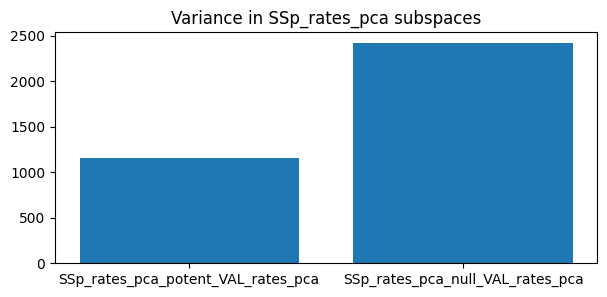

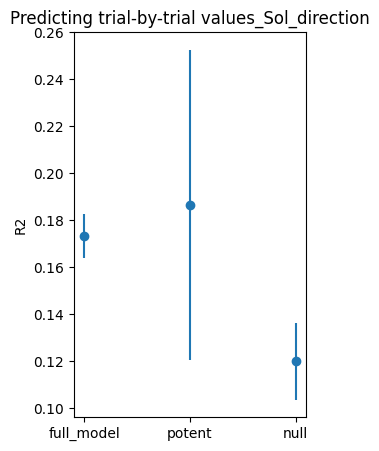

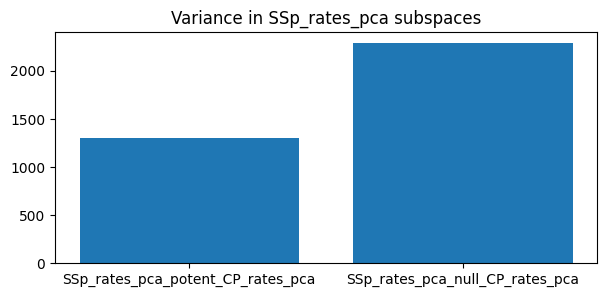

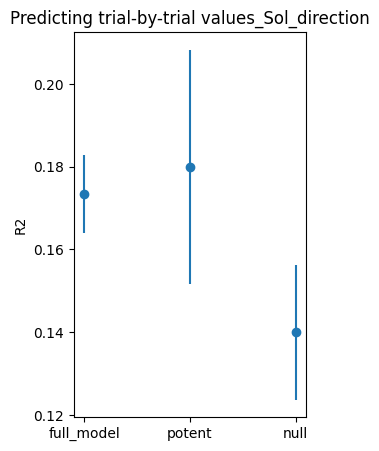

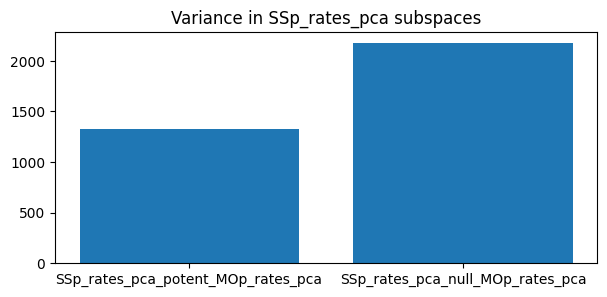

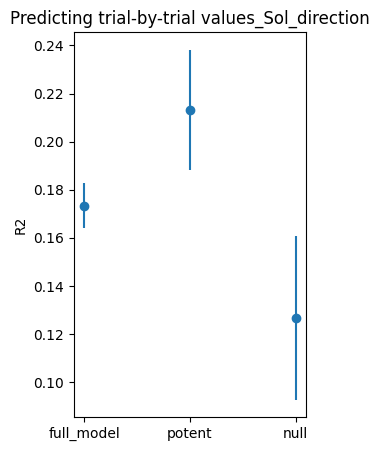

In [168]:
for area in ['VAL', 'CP', 'MOp']:
    privatise_and_decode(
        df_tr_sliced,
        n_iter = 2,
        origin_signal='SSp_rates_pca',
        target_signal=f'{area}_rates_pca',
        rank=20,
        idx_disturb_to_keep = sorted(dstrb_idx[:150]),
        target_var = 'values_Sol_direction',
        model = GaussianNB(),
        window_dec=(200, 500),
        scorer='accuracy',
        cv=StratifiedKFold(n_splits=3, shuffle=False)
    )

# Refactored version v2

In [13]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [14]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [15]:
df__ = dt.add_pca_df(df_)

In [16]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [7]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'MOp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'SSp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'CP_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'VAL_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]


# Add instantaneous phase
df_tr["perturb_phase"] = df_tr["phases"].apply(lambda a: a[300, :])
df_tr['disturb_sum'] = df_tr['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_tr['disturb_mean'] = df_tr['disturb_score'].apply(lambda a: np.mean(a))


disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 17 of 333 rows (5.11%).


In [297]:
df_design = df_tr.copy()

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

### Privatise signals

In [298]:
origin_signal = 'VAL_rates_pca'
target_signal='MOp_rates_pca'
n_iter = 2
perturb_td_shuff, r2s, vars = subspaces.privatise_signal_td(
    perturb_td_shuff,
    n_iter=n_iter,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=50,
    diagnostics=True
    )

perturb_td_shuff, r2, var = subspaces.publicise_signal_td(
    perturb_td_shuff,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=50,
    )

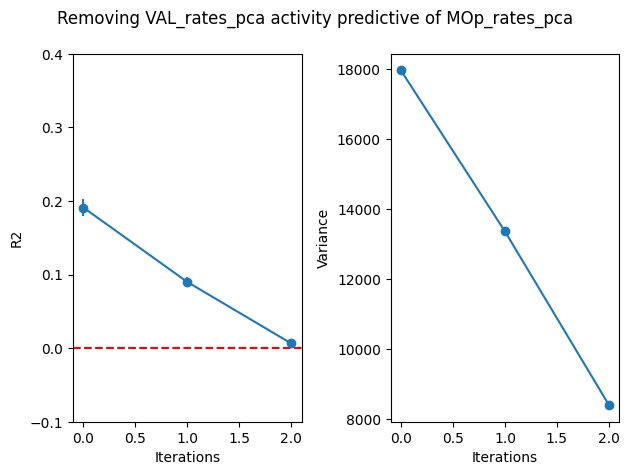

In [103]:
fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')
ax[0].errorbar(range(n_iter+1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(n_iter+1), np.array(vars), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()
plt.show()

In [8]:

def majority_class_chance_levels_from_counts(counts):
    """
    counts_dict: {class_label: count, ...}
    Returns:
      N, majority_chance, prior_weighted_chance, uniform_chance
    """
    N = counts.sum()

    majority_chance = counts.max() / N

    return majority_chance


def drop_classes_below_count(X, y, *, min_count=1, return_mask=False):
    """
    Drop all samples belonging to classes in y with count < min_count.

    Parameters
    ----------
    X : array-like, shape (n_samples, ...)
    y : array-like, shape (n_samples,)
    min_count : int
        Classes with fewer than min_count samples are dropped.
    return_mask : bool
        If True, also return the boolean mask used to keep samples.

    Returns
    -------
    X_kept, y_kept, weight  (and mask if return_mask=True)
    """
    X = np.asarray(X)
    y = np.asarray(y)

    if X.shape[0] != y.shape[0]:
        raise ValueError(f"X and y must have same number of samples. Got {X.shape[0]} and {y.shape[0]}.")

    classes, counts = np.unique(y, return_counts=True)



    if classes.size < 2:
        mask = np.ones_like(y, dtype=bool)
        chance = majority_class_chance_levels_from_counts(counts)
        return (X, y, mask, chance) if return_mask else (X, y, chance)

    drop_classes = classes[counts < min_count]

    if drop_classes.size == 0:
        # Nothing to drop
        mask = np.ones_like(y, dtype=bool)
        chance = majority_class_chance_levels_from_counts(counts)
        return (X, y, mask, chance) if return_mask else (X, y, chance)

    print(f"Dropping classes with count < {min_count}: {drop_classes.tolist()}")
    print(f"Counts: {dict(zip(classes.tolist(), counts.tolist()))}")


    mask = ~np.isin(y, drop_classes)

    X_kept = X[mask]
    y_kept = y[mask]
    classes, counts = np.unique(y_kept, return_counts=True)
    chance = majority_class_chance_levels_from_counts(counts)

    return (X_kept, y_kept, mask, chance) if return_mask else (X_kept, y_kept, chance)


In [321]:
idx = sorted(dstrb_idx[:100])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=100,
    step_bin=2
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=100,
    step_bin=2
)
scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=100,
    step_bin=2
)

Dropping classes with count < 3: [0, 4]
Counts: {0: 2, 1: 17, 2: 16, 3: 14, 4: 2, 5: 14, 6: 10, 7: 3, 8: 7, 9: 4, 10: 7, 11: 4}


100%|██████████| 201/201 [00:02<00:00, 78.23it/s]


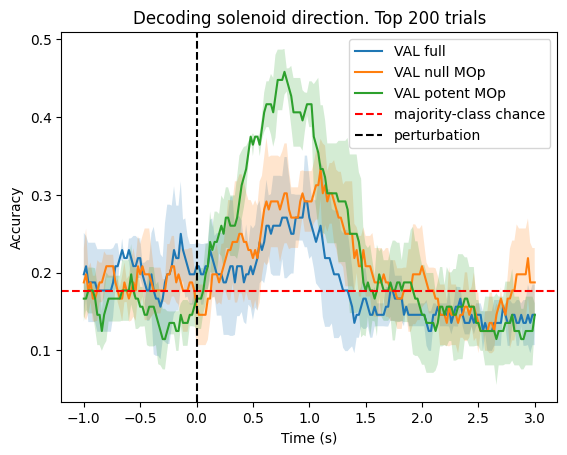

In [322]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label='VAL full')
vizutils.shaded_errorbar(ax, times-2, scores_null, label='VAL null MOp')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='VAL potent MOp')

ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Decoding solenoid direction. Top 200 trials')

ax.legend()

In [317]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

idx = sorted(dstrb_idx[:100])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
y = perturb_td_shuff_filt.disturb_sum.values

# X_filt, y_filt, mask, _ = drop_classes_below_count(X, y, min_count=3, return_mask=True)



n_trials, _, _ = X.shape
scores_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)
scores_full, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)
scores_potent, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)

 21%|██        | 42/201 [00:00<00:03, 41.39it/s]

100%|██████████| 201/201 [00:02<00:00, 71.30it/s]


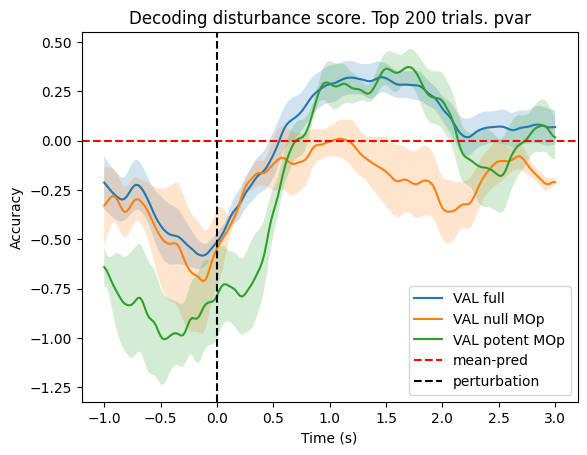

In [318]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label='VAL full')
vizutils.shaded_errorbar(ax, times-2, scores_null, label='VAL null MOp')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='VAL potent MOp')

ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Decoding disturbance score. Top 200 trials. pvar')
# ax.set_ylim(-0.2, 0.5)

ax.legend()

In [313]:
idx = sorted(dstrb_idx[:200])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
y = perturb_td_shuff_filt.values_Sol_duration.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=4),
    window_length_bin=100,
    step_bin=2
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=4),
    window_length_bin=100,
    step_bin=2
)

scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=4),
    window_length_bin=100,
    step_bin=2
)

100%|██████████| 201/201 [00:03<00:00, 51.46it/s]


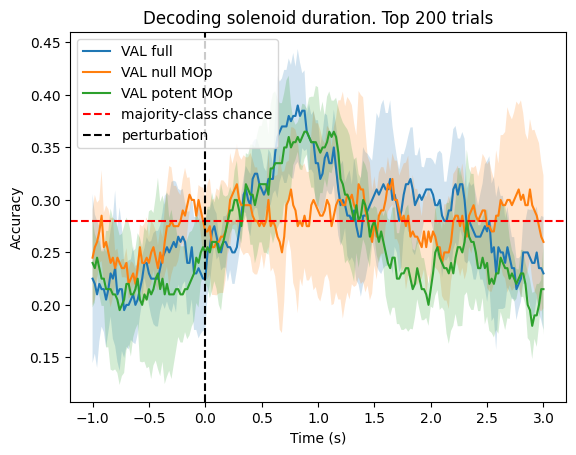

In [314]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label='VAL full')
vizutils.shaded_errorbar(ax, times-2, scores_null, label='VAL null MOp')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='VAL potent MOp')

ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Decoding solenoid duration. Top 200 trials')

ax.legend()

## VAL to all areas

Remaining null space var 8494.837885893015. Potent var 4378.909835706939


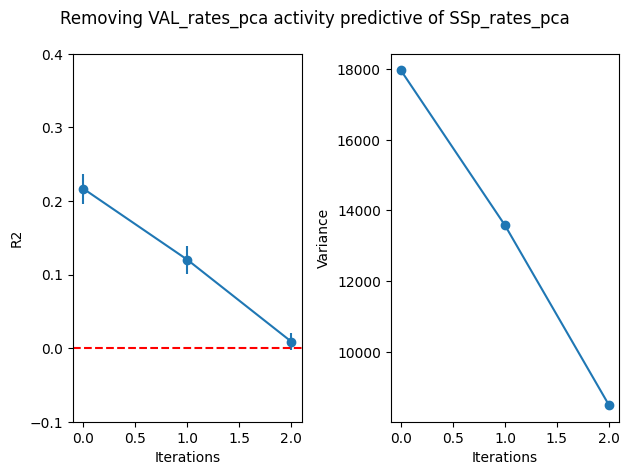

100%|██████████| 201/201 [00:02<00:00, 73.48it/s]


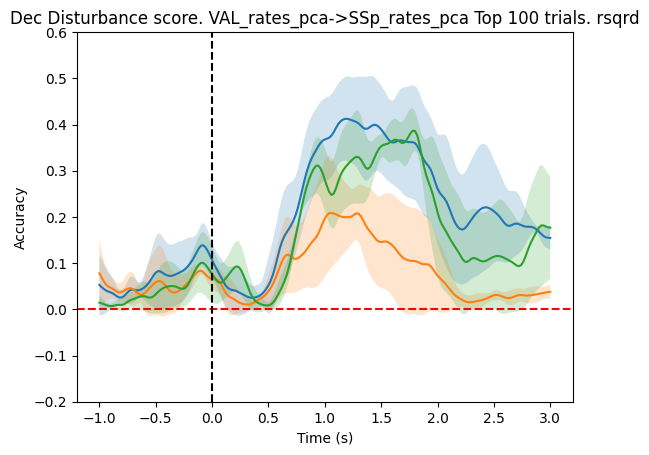

In [334]:
origin_signal = 'VAL_rates_pca'
target_signal='SSp_rates_pca'

idx_to_keep = 100
df_design = df_tr.copy()

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

n_iter = 2
perturb_td_shuff, r2s, vars = subspaces.privatise_signal_td(
    perturb_td_shuff,
    n_iter=n_iter,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=50,
    diagnostics=True
    )

perturb_td_shuff, r2, var = subspaces.publicise_signal_td(
    perturb_td_shuff,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=50,
    )
print(f'Remaining null space var {vars[-1]}. Potent var {var}')
fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')
ax[0].errorbar(range(n_iter+1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(n_iter+1), np.array(vars), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()
plt.show()

# idx = sorted(dstrb_idx[:idx_to_keep])
# perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# # perturb_td_shuff_filt = (
# #     perturb_td_shuff_filt
# #     .sort_values(by='trial_id')
# #     .reset_index(drop=True)
# # )
# X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
# y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

# X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

# n_trials, _, _ = X.shape
# scores_null, times = decode.moving_window_decoding(
#     X_filt,
#     y_filt,
#     cv=StratifiedKFold(n_splits=3),
#     window_length_bin=100,
#     step_bin=2
# )
# scores_full, times = decode.moving_window_decoding(
#     np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
#     y_filt,
#     cv=StratifiedKFold(n_splits=3),
#     window_length_bin=100,
#     step_bin=2
# )
# scores_potent, times = decode.moving_window_decoding(
#     np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
#     y_filt,
#     cv=StratifiedKFold(n_splits=3),
#     window_length_bin=100,
#     step_bin=2
# )

# fig, ax = plt.subplots()
# vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'{origin_signal} full')
# vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'{origin_signal} null {target_signal}')
# vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'{origin_signal} potent {target_signal}')

# ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
# ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

# ax.set_xlabel('Time (s)')
# ax.set_ylabel('Accuracy')
# ax.set_title('Decoding solenoid direction. Top 200 trials')

# ax.legend()
# plt.show()

# vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
y = perturb_td_shuff_filt.disturb_sum.values



n_trials, _, _ = X.shape
scores_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    # scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)
scores_full, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    # scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)
scores_potent, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    # scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)

fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'{origin_signal} full')
vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'{origin_signal} null {target_signal}')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'{origin_signal} potent {target_signal}')

ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Dec Disturbance score. {origin_signal}->{target_signal} Top {idx_to_keep} trials. rsqrd')
ax.set_ylim(-0.2, 0.6)

# ax.legend()
plt.show()

# idx = sorted(dstrb_idx[:200])
# perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# # perturb_td_shuff_filt = (
# #     perturb_td_shuff_filt
# #     .sort_values(by='trial_id')
# #     .reset_index(drop=True)
# # )
# X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
# y = perturb_td_shuff_filt.values_Sol_duration.values.tolist()

# X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

# n_trials, _, _ = X.shape
# scores_null, times = decode.moving_window_decoding(
#     X_filt,
#     y_filt,
#     cv=StratifiedKFold(n_splits=4),
#     window_length_bin=100,
#     step_bin=2
# )
# scores_full, times = decode.moving_window_decoding(
#     np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
#     y_filt,
#     cv=StratifiedKFold(n_splits=4),
#     window_length_bin=100,
#     step_bin=2
# )

# scores_potent, times = decode.moving_window_decoding(
#     np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
#     y_filt,
#     cv=StratifiedKFold(n_splits=4),
#     window_length_bin=100,
#     step_bin=2
# )

# fig, ax = plt.subplots()
# vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'{origin_signal} full')
# vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'{origin_signal} null {target_signal}')
# vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'{origin_signal} potent {target_signal}')

# ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
# ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

# ax.set_xlabel('Time (s)')
# ax.set_ylabel('Accuracy')
# ax.set_title('Decoding solenoid duration. Top 200 trials')

# ax.legend()
# plt.show()

Remaining null space var 1758.6116047641904. Potent var 2271.3663266570807


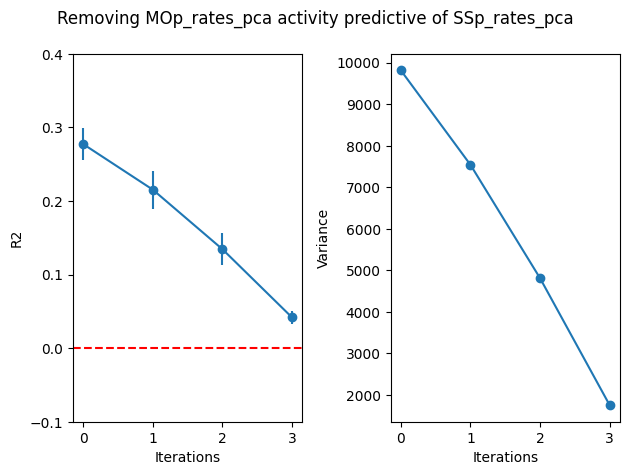

100%|██████████| 226/226 [00:02<00:00, 100.21it/s]


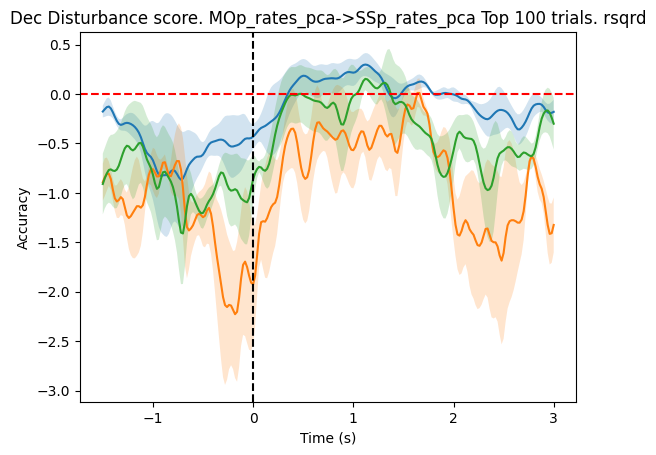

In [ ]:
origin_signal = 'MOp_rates_pca'
idx_to_keep = 100
rank = 50
window = 100
n_iter = 3

for area in ['SSp']:
    target_signal=f'{area}_rates_pca'

    df_design = df_tr.copy()

    perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
    perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

    perturb_td_shuff, r2s, vars = subspaces.privatise_signal_td(
        perturb_td_shuff,
        n_iter=n_iter,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        diagnostics=True
        )

    perturb_td_shuff, r2, var = subspaces.publicise_signal_td(
        perturb_td_shuff,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        )
    print(f'Remaining null space var {vars[-1]}. Potent var {var}')
    fig, ax = plt.subplots(1, 2)
    plt.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')
    ax[0].errorbar(range(n_iter+1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
    ax[0].set_ylim(-0.1, 0.4)
    ax[0].axhline(0, color= 'r', linestyle='dashed')
    ax[0].set_xlabel('Iterations')
    ax[0].set_ylabel('R2')
    ax[1].errorbar(range(n_iter+1), np.array(vars), fmt='o-')
    ax[1].set_xlabel('Iterations')
    ax[1].set_ylabel('Variance')

    # ax[1].set_ylim(-0.1, 0.4)
    plt.tight_layout()
    plt.show()

    idx = sorted(dstrb_idx[:idx_to_keep])
    perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
    # perturb_td_shuff_filt = (
    #     perturb_td_shuff_filt
    #     .sort_values(by='trial_id')
    #     .reset_index(drop=True)
    # )
    y = perturb_td_shuff_filt.disturb_sum.values



    n_trials, _, _ = X.shape
    scores_null, times = decode.decoding_moving_window_no_time_concat(
        Ridge(1000),
        np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values),
        y,
        cv=KFold(n_splits=4),
        scorer=vw_r2_scorer,
        window_length_bin=window,
        step_bin=2
    )
    scores_full, times = decode.decoding_moving_window_no_time_concat(
        Ridge(1000),
        np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values),
        y,
        cv=KFold(n_splits=4),
        scorer=vw_r2_scorer,
        window_length_bin=window,
        step_bin=2
    )
    scores_potent, times = decode.decoding_moving_window_no_time_concat(
        Ridge(1000),
        np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values),
        y,
        cv=KFold(n_splits=4),
        scorer=vw_r2_scorer,
        window_length_bin=window,
        step_bin=2
    )

    fig, ax = plt.subplots()
    vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'{origin_signal} full')
    vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'{origin_signal} null {target_signal}')
    vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'{origin_signal} potent {target_signal}')

    ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
    ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Dec Disturbance score. {origin_signal}->{target_signal} Top {idx_to_keep} trials. rsqrd')
    # ax.set_ylim(-0.2, 0.6)

    # ax.legend()
    plt.show()

In [426]:
origin_signal = 'VAL_rates_pca'
idx_to_keep = 90
rank = 50
window = 100
n_iter = 2

tmp_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)

var_rank_spaces = subspaces.variance_in_dims(
    np.concatenate(tmp_td[origin_signal].values)[:, :rank],
    np.eye(rank)
)
print(f'Variance in rank {rank} space : {np.sum(var_rank_spaces)}')
for area in ['CP']:
    target_signal=f'{area}_rates_pca'

    df_design = df_tr.copy()

    perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
    perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

    perturb_td_shuff, r2s, vars = subspaces.privatise_signal_td(
        perturb_td_shuff,
        n_iter=n_iter,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        diagnostics=True
        )

    perturb_td_shuff, r2, var = subspaces.publicise_signal_td(
        perturb_td_shuff,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        )

    idx = sorted(dstrb_idx[:idx_to_keep])
    perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
    X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
    y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

    X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

    n_trials, _, _ = X.shape
    scores_null, times = decode.moving_window_decoding(
        X_filt,
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )
    scores_full, times = decode.moving_window_decoding(
        np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask, :, :],
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )
    scores_potent, times = decode.moving_window_decoding(
        np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )

    

Variance in rank 50 space : 10847.725932329895
Dropping classes with count < 3: [0, 4, 7]
Counts: {0: 2, 1: 16, 2: 14, 3: 12, 4: 2, 5: 13, 6: 10, 7: 2, 8: 7, 9: 4, 10: 5, 11: 3}


100%|██████████| 201/201 [00:02<00:00, 84.98it/s]


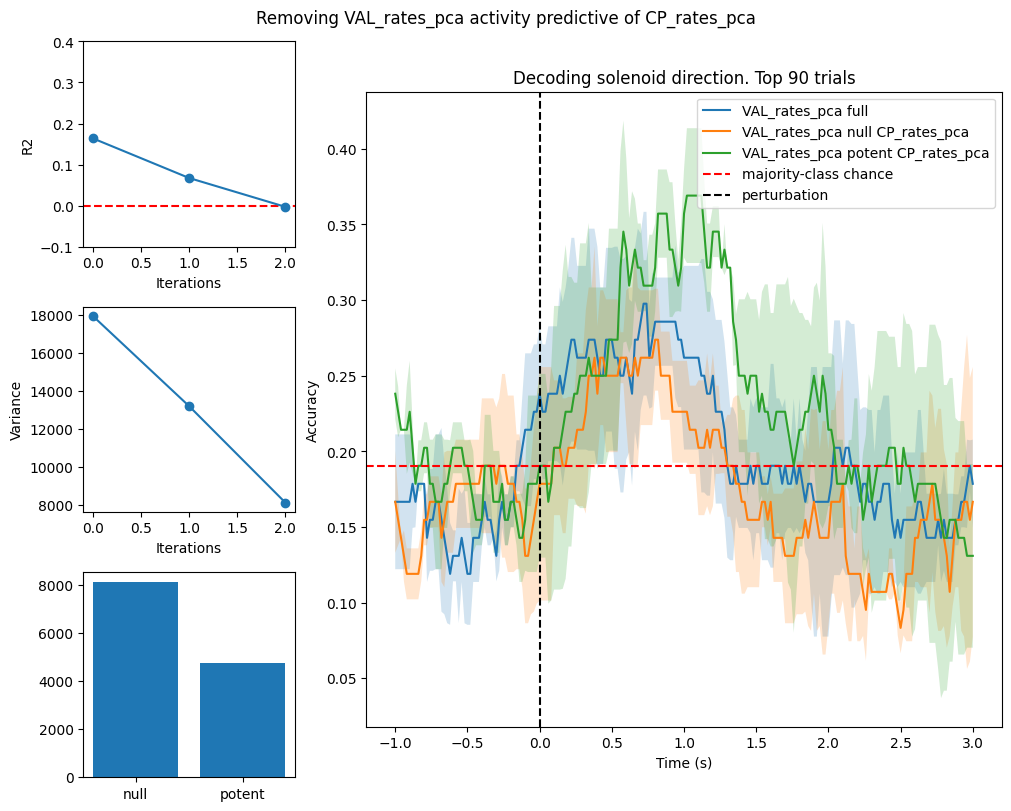

In [427]:
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, width_ratios=[0.5, 1.5])

# Left column (3 rows)
ax_r2   = fig.add_subplot(gs[0, 0])
ax_var  = fig.add_subplot(gs[1, 0])
ax_left3 = fig.add_subplot(gs[2, 0])   # optional third left plot

# Right column (one big axis spanning all 3 rows)
ax_big = fig.add_subplot(gs[:, 1])

fig.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')

# --- Left top: R2 ---
ax_r2.errorbar(range(n_iter + 1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax_r2.set_ylim(-0.1, 0.4)
ax_r2.axhline(0, color='r', linestyle='dashed')
ax_r2.set_xlabel('Iterations')
ax_r2.set_ylabel('R2')

# --- Left middle: Variance ---
ax_var.plot(range(n_iter + 1), np.array(vars), 'o-')
ax_var.set_xlabel('Iterations')
ax_var.set_ylabel('Variance')

# --- Left bottom: (optional) ---
# If you don't want anything here, delete ax_left3 or turn it off:
ax_left3.bar(['null', 'potent'], [vars[-1], var])
# Or put something here (e.g., potent/null variance split, histogram, etc.)

# --- Right big: decoding timecourse ---
vizutils.shaded_errorbar(ax_big, times - 2, scores_full,   label=f'{origin_signal} full')
vizutils.shaded_errorbar(ax_big, times - 2, scores_null,   label=f'{origin_signal} null {target_signal}')
vizutils.shaded_errorbar(ax_big, times - 2, scores_potent, label=f'{origin_signal} potent {target_signal}')

ax_big.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax_big.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax_big.set_xlabel('Time (s)')
ax_big.set_ylabel('Accuracy')
ax_big.set_title(f'Decoding solenoid direction. Top {idx_to_keep} trials')
ax_big.legend()

# Make the right panel square-ish (box aspect = 1 makes it visually square)
ax_big.set_box_aspect(1)
# ax_big.set_xlim(-0.5, 1.5)

plt.show()

In [416]:
origin_signal = 'MOp_rates_pca'
idx_to_keep = 100
rank = 30
window = 30
n_iter = 4

tmp_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)

var_rank_spaces = subspaces.variance_in_dims(
    np.concatenate(tmp_td[origin_signal].values)[:, :rank],
    np.eye(rank)
)
print(f'Variance in rank {rank} space : {np.sum(var_rank_spaces)}')
for area in ['SSp']:
    target_signal=f'{area}_rates_pca'

    df_design = df_tr.copy()

    perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
    perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

    perturb_td_shuff, r2s, vars = subspaces.privatise_signal_td(
        perturb_td_shuff,
        n_iter=n_iter,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        diagnostics=True
        )

    perturb_td_shuff, r2, var = subspaces.publicise_signal_td(
        perturb_td_shuff,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        )

    idx = sorted(dstrb_idx[:idx_to_keep])
    perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
    X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
    y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

    X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

    n_trials, _, _ = X.shape
    scores_null, times = decode.moving_window_decoding(
        X_filt,
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )
    scores_full, times = decode.moving_window_decoding(
        np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask, :, :],
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )
    scores_potent, times = decode.moving_window_decoding(
        np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )

    

Variance in rank 30 space : 6073.92137418684
Dropping classes with count < 3: [0, 4]
Counts: {0: 2, 1: 17, 2: 16, 3: 14, 4: 2, 5: 14, 6: 10, 7: 3, 8: 7, 9: 4, 10: 7, 11: 4}


100%|██████████| 236/236 [00:01<00:00, 157.16it/s]


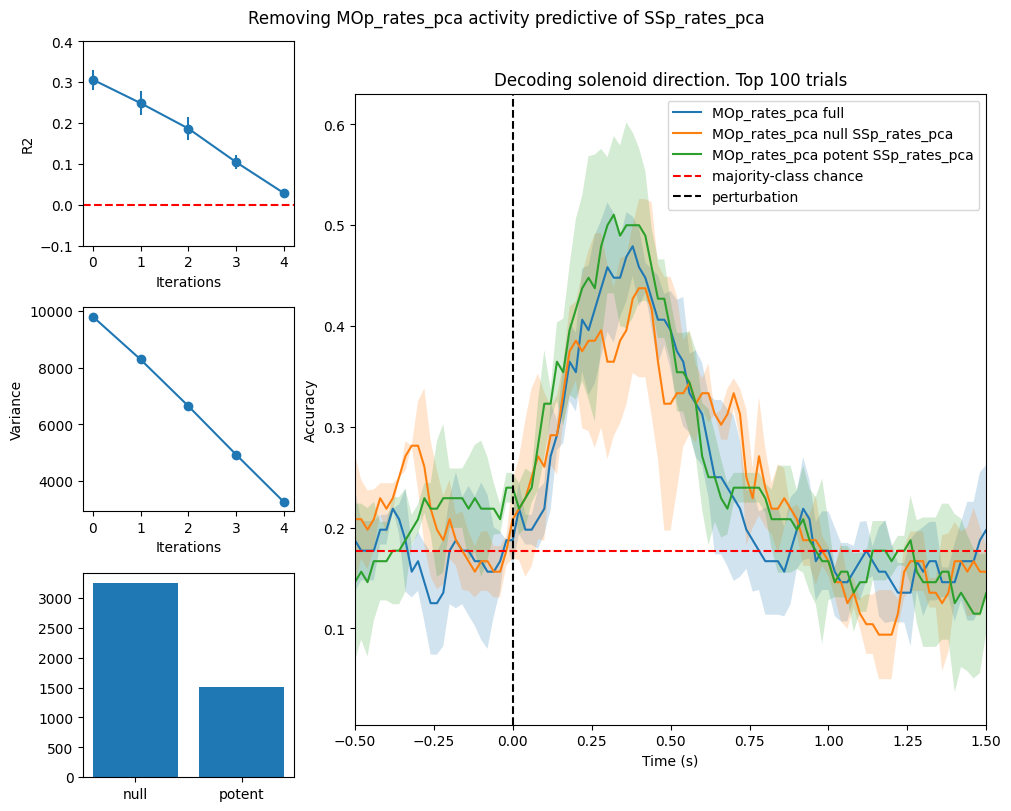

In [417]:
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, width_ratios=[0.5, 1.5])

# Left column (3 rows)
ax_r2   = fig.add_subplot(gs[0, 0])
ax_var  = fig.add_subplot(gs[1, 0])
ax_left3 = fig.add_subplot(gs[2, 0])   # optional third left plot

# Right column (one big axis spanning all 3 rows)
ax_big = fig.add_subplot(gs[:, 1])

fig.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')

# --- Left top: R2 ---
ax_r2.errorbar(range(n_iter + 1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax_r2.set_ylim(-0.1, 0.4)
ax_r2.axhline(0, color='r', linestyle='dashed')
ax_r2.set_xlabel('Iterations')
ax_r2.set_ylabel('R2')

# --- Left middle: Variance ---
ax_var.plot(range(n_iter + 1), np.array(vars), 'o-')
ax_var.set_xlabel('Iterations')
ax_var.set_ylabel('Variance')

# --- Left bottom: (optional) ---
# If you don't want anything here, delete ax_left3 or turn it off:
ax_left3.bar(['null', 'potent'], [vars[-1], var])
# Or put something here (e.g., potent/null variance split, histogram, etc.)

# --- Right big: decoding timecourse ---
vizutils.shaded_errorbar(ax_big, times - 2, scores_full,   label=f'{origin_signal} full')
vizutils.shaded_errorbar(ax_big, times - 2, scores_null,   label=f'{origin_signal} null {target_signal}')
vizutils.shaded_errorbar(ax_big, times - 2, scores_potent, label=f'{origin_signal} potent {target_signal}')

ax_big.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax_big.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax_big.set_xlabel('Time (s)')
ax_big.set_ylabel('Accuracy')
ax_big.set_title(f'Decoding solenoid direction. Top {idx_to_keep} trials')
ax_big.legend()
ax_big.set_xlim(-0.5, 1.5)

# Make the right panel square-ish (box aspect = 1 makes it visually square)
ax_big.set_box_aspect(1)

plt.show()

## VAL private to m1 and cp?

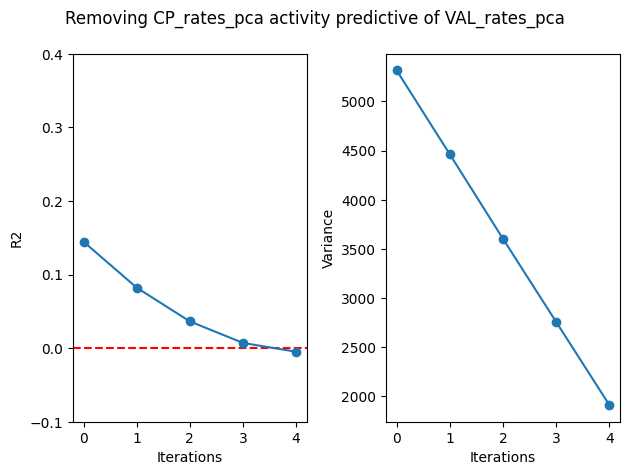

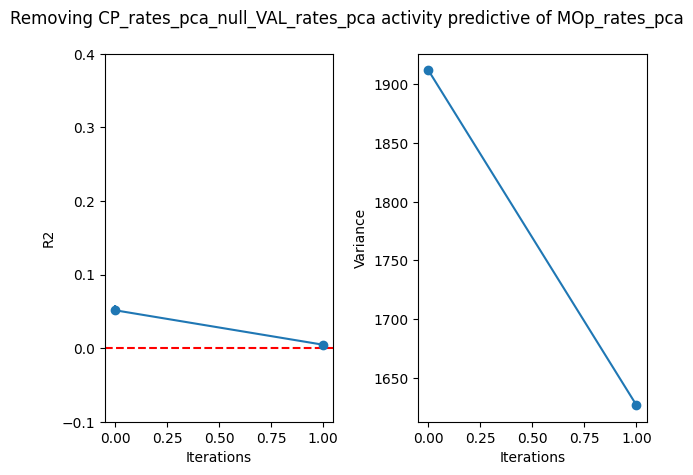

In [106]:
origin_signal = 'CP_rates_pca'
target_signal='VAL_rates_pca'

idx_to_keep = 100
df_design = df_tr.copy()

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

perturb_td_shuff = subspaces.publicise_signal_td(
    perturb_td_shuff,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=30,
    )

n_iter = 4
perturb_td_shuff = subspaces.privatise_signal_td(
    perturb_td_shuff,
    n_iter=n_iter,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=30,
    diagnostics=True
    )
n_iter = 1
perturb_td_shuff = subspaces.privatise_signal_td(
    perturb_td_shuff,
    n_iter=n_iter,
    origin_signal='CP_rates_pca_null_VAL_rates_pca',
    target_signal='MOp_rates_pca',
    rank=10,
    diagnostics=True
    )


In [648]:
vars_potent

2735.9480047017137

In [519]:
perturb_td_shuff.CP_rates_pca_potent_MOp_rates_pca.values[0].shape

(501, 30)

In [520]:
perturb_td_shuff.CP_rates_pca_null_MOp_rates_pca_null_VAL_rates_pca.values[0].shape

(501, 52)

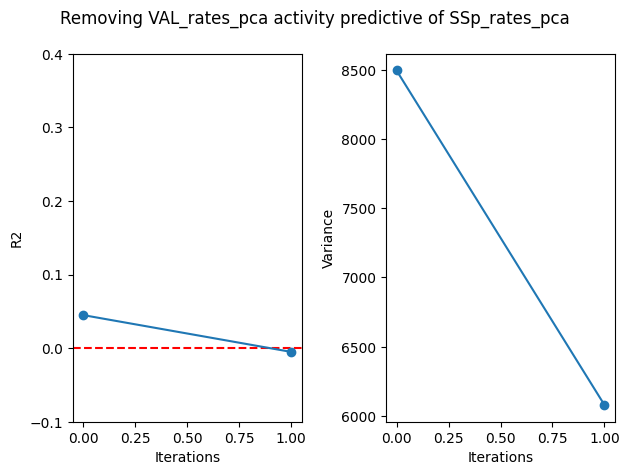

In [662]:
fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')
ax[0].errorbar(range(n_iter+1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(n_iter+1), np.array(vars), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')
plt.tight_layout()

### Decode perturbation score

In [663]:
idx_to_keep = 100
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
y = np.concatenate(perturb_td_shuff_filt.disturb_score.values)
window = 100


scores_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=window,
    step_bin=2
)
scores_null_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}_null_MOp_rates_pca'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=window,
    step_bin=2
)
scores_full, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=window,
    step_bin=2
)
scores_potent, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=window,
    step_bin=2
)



  0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 201/201 [00:03<00:00, 66.31it/s]


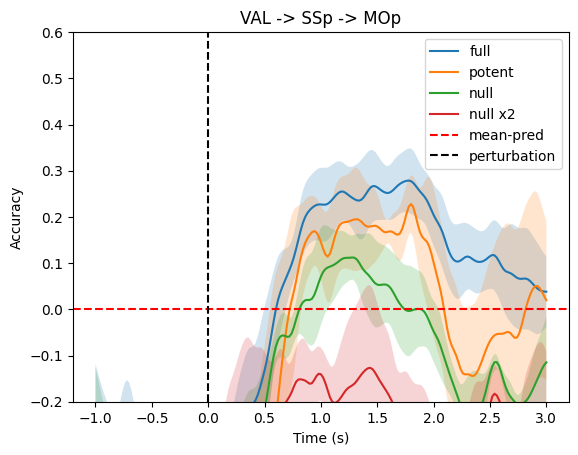

In [665]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'full')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'potent')

vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'null')
vizutils.shaded_errorbar(ax, times-2, scores_null_null, label=f'null x2')


ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'VAL -> SSp -> MOp')
ax.set_ylim(-0.2, 0.6)

ax.legend()
plt.show()

### Decode solenoid direction

In [107]:
idx_to_keep = 150
window = 100
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
X = np.stack(perturb_td_shuff_filt['CP_rates_pca_null_VAL_rates_pca'].values)
y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=2
)
scores_null_null, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt['CP_rates_pca_null_VAL_rates_pca_null_MOp_rates_pca'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=2
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask, :, :],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=2
)
scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=2
)

  0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 201/201 [00:02<00:00, 73.88it/s]


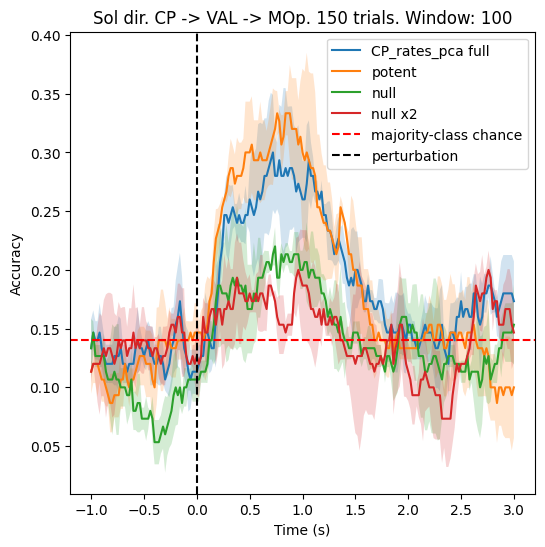

In [109]:
fig, ax = plt.subplots(figsize=(6, 6))
vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'{origin_signal} full')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'potent')

vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'null')
vizutils.shaded_errorbar(ax, times-2, scores_null_null, label=f'null x2')


ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Sol dir. CP -> VAL -> MOp. {idx_to_keep} trials. Window: {window}')
# ax.set_xlim(-1, 2)
ax.legend()
# ax.set_ylim(0, 0.37)
plt.show()



# VAL var during perturb pre-perturb embedding

In [137]:
df_design = df_tr.copy()

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

In [138]:
areas = ['MOp', 'CP', 'SSp', 'VAL']
window_emb = (0, 200)
vars = {}
rank = 30
for area_a in areas:
    vars[area_a] = {}
    for area_b in areas:
        if area_b == area_a:
            continue
        emb = subspaces.compute_embedding(
            perturb_td_shuff,
            f"{area_a}_rates_pca",
            f"{area_b}_rates_pca",
            (window_emb[0], window_emb[-1]),
            subspaces.ReducedRankCommSubspace(rank=rank),
        )
        perturb_td_shuff = subspaces.project_signal(
            perturb_td_shuff,
            emb,
            f'{area_a}_rates_pca',
            f'{area_a}_potent_{area_b}'
        )
        vars[area_a][area_b] = subspaces.variance_in_subspace_df(
            perturb_td_shuff,
            f'{area_a}_rates_pca',
            emb
        )


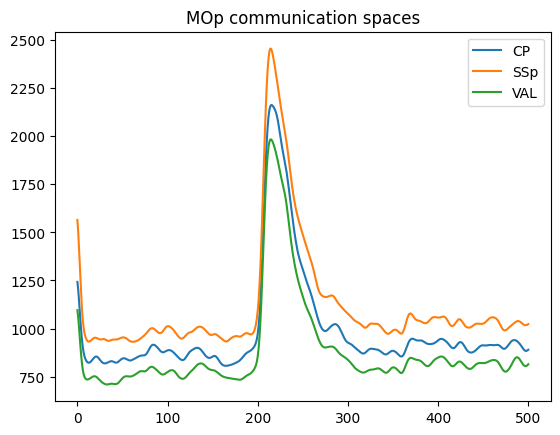

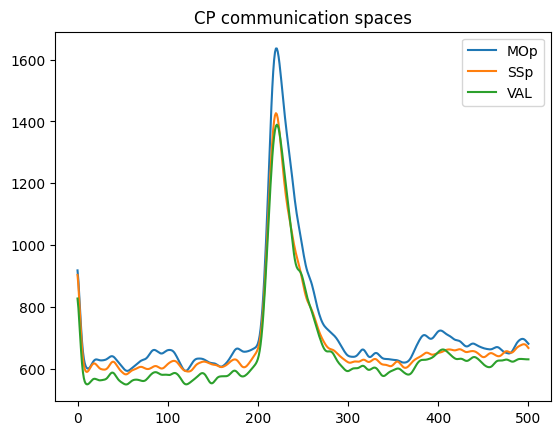

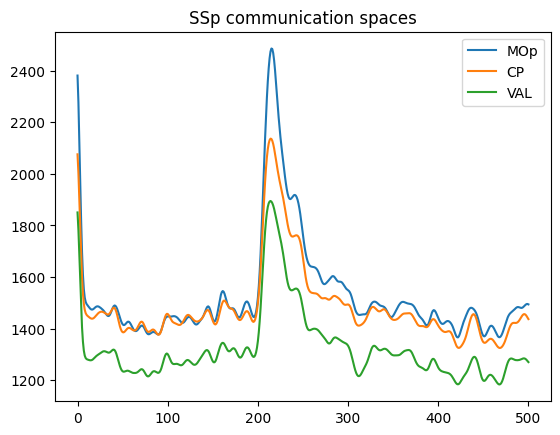

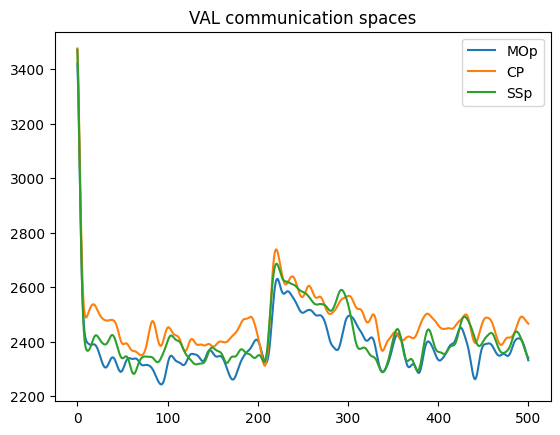

In [42]:
for area_a in vars.keys():
    fig, ax = plt.subplots()
    for area_b in vars[area_a].keys():
        ax.plot(vars[area_a][area_b], label=area_b)
        ax.set_title(f'{area_a} communication spaces')
        ax.legend()
    

In [12]:
perturb_td_shuff.columns

Index(['index', 'animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'all_chan_best', 'all_unit_guide',
 

In [26]:
df_design = df_tr.copy()

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

Private var: 1840653.5631130878. Public var: 583616.5779498902
Private var: 4176316.7526402343. Public var: 2193113.286100284


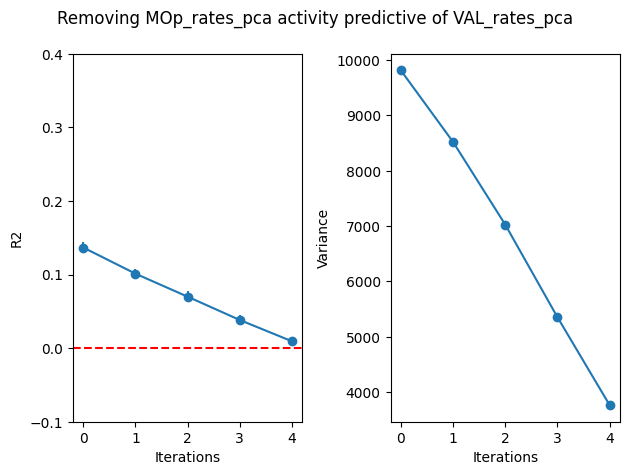

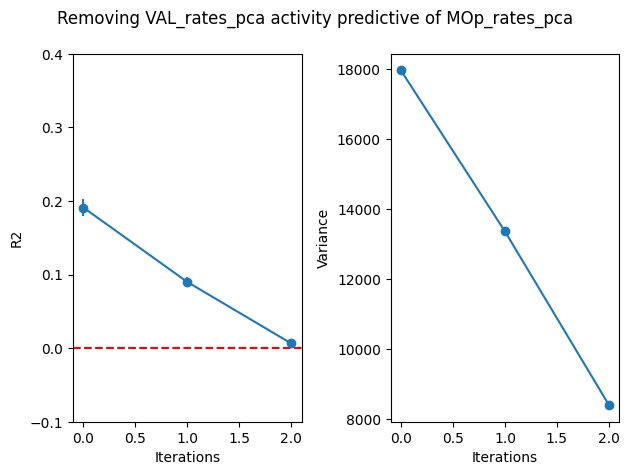

In [169]:
df_design = df_tr.copy()
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

areas = ['MOp', 'VAL', 'CP', 'SSp']
iter_dict = {
    'MOp': 4,
    'CP': 4,
    'VAL': 2,
    'SSp': 3
}
window_emb = (0, 500)
vars = {}
rank_dict = {
    'MOp': 30,
    'CP': 30,
    'VAL': 50,
    'SSp': 10
}
for area_a in areas[:2]:
    vars[area_a] = {}
    for area_b in areas[:2]:
        if area_b == area_a:
            # n_pcs = np.stack(
            #     perturb_td_shuff[f'{area_a}_rates_pca'].values[0]
            # ).shape[-1]
            # vars[area_a][area_b] = subspaces.variance_in_subspace_df(
            #     perturb_td_shuff,
            #     f'{area_a}_rates_pca',
            #     np.eye(n_pcs)
            # )
            continue
        perturb_td_shuff = subspaces.publicise_signal_td(
            perturb_td_shuff,
            origin_signal=f"{area_a}_rates_pca",
            target_signal=f"{area_b}_rates_pca",
            rank=rank_dict[area_a],
            window_emb=window_emb,
        )
        perturb_td_shuff = subspaces.privatise_signal_td(
            perturb_td_shuff,
            n_iter=iter_dict[area_a],
            origin_signal=f"{area_a}_rates_pca",
            target_signal=f"{area_b}_rates_pca",
            rank=rank_dict[area_a],
            window_emb=window_emb,
            diagnostics=True
        )
        dim_null = np.stack(
            perturb_td_shuff[f'{area_a}_rates_pca_null_{area_b}_rates_pca'].values[0]
        ).shape[-1]
        vars[area_a][area_b] = subspaces.variance_in_subspace_df(
            perturb_td_shuff,
            f'{area_a}_rates_pca_null_{area_b}_rates_pca',
            np.eye(dim_null)
        )
        public_var = subspaces.variance_in_subspace_df(
            perturb_td_shuff,
            f'{area_a}_rates_pca_potent_{area_b}_rates_pca',
            np.eye(rank_dict[area_a])
        )
        print(f'Private var: {np.sum(vars[area_a][area_b])}. Public var: {np.sum(public_var)}')


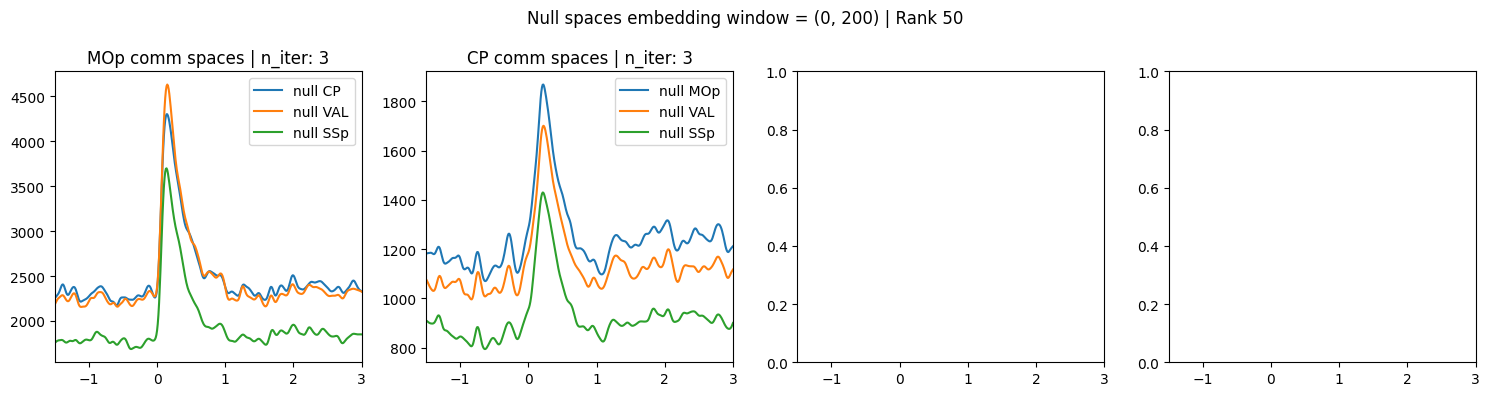

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharex='all')
times = (np.arange(0, 501) / 100) - 2
for area_a, ax in zip(vars.keys(), axs):
    for area_b in vars[area_a].keys():
        if area_a == area_b:
            label = 'full'
        else:
            label = f"null {area_b}"
        ax.plot(times, vars[area_a][area_b], label=label)
        ax.set_title(f'{area_a} comm spaces | n_iter: {iter_dict[area_a]}')
        ax.legend()
        ax.set_xlim(-1.5, 3)
plt.suptitle(f'Null spaces embedding window = {window_emb} | Rank {50}')
plt.tight_layout()

## MOp null comm subspaces

In [176]:
idx_to_keep = 100
window = 100
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
origin_signal = 'MOp_rates_pca'
target_signal = 'VAL_rates_pca'

X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)

Dropping classes with count < 3: [0, 4]
Counts: {0: 2, 1: 17, 2: 16, 3: 14, 4: 2, 5: 14, 6: 10, 7: 3, 8: 7, 9: 4, 10: 7, 11: 4}


  0%|          | 0/402 [00:00<?, ?it/s]

100%|██████████| 402/402 [00:04<00:00, 94.94it/s]


(0.0, 0.5)

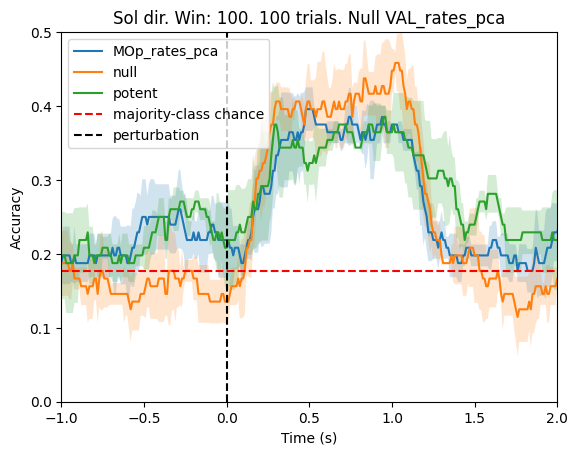

In [177]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=origin_signal)
vizutils.shaded_errorbar(ax, times-2, scores_null, label='null')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='potent')


ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Sol dir. Win: {window}. {idx_to_keep} trials. Null {target_signal}')

ax.legend()
ax.set_xlim(-1, 2)
ax.set_ylim(0, 0.5)

In [155]:
origin_signal ='MOp_rates_pca'
target_signal = 'VAL_rates_pca'
scorer = make_scorer(r2_score)

idx_to_keep=(0, 200)
window = 50
idx = sorted(dstrb_idx[idx_to_keep[0]:idx_to_keep[1]])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
y = perturb_td_shuff_filt.disturb_sum.values
# y = np.concatenate(perturb_td_shuff_filt.disturb_score.values)


def opt_ridge_alpha(x_cv, y_cv):
    alphas = np.logspace(-10, 4, 50)
    ridge_cv = RidgeCV(alphas=alphas)
    ridge_cv.fit(x_cv, y_cv)
    return ridge_cv.alpha_

X_null = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
alpha = opt_ridge_alpha(
        X_null.reshape(X_null.shape[0], -1), 
        y
    )
print(alpha)
scores_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(alpha, solver='lsqr'),
    X_null,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

X_full = np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)
alpha = opt_ridge_alpha(
        X_full.reshape(X_full.shape[0], -1), 
        y
    )
print(alpha)
scores_full, times = decode.decoding_moving_window_no_time_concat(
    Ridge(solver='lsqr'),
    X_full,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

X_potent = np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)
alpha = opt_ridge_alpha(
        X_potent.reshape(X_potent.shape[0], -1), 
        y
    )
print(alpha)
scores_potent, times = decode.decoding_moving_window_no_time_concat(
    Ridge(alpha, solver='lsqr'),
    X_potent,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

10000.0


100%|██████████| 226/226 [00:04<00:00, 48.72it/s]


1e-10


100%|██████████| 226/226 [00:07<00:00, 30.90it/s]


10000.0


100%|██████████| 226/226 [00:02<00:00, 91.17it/s]


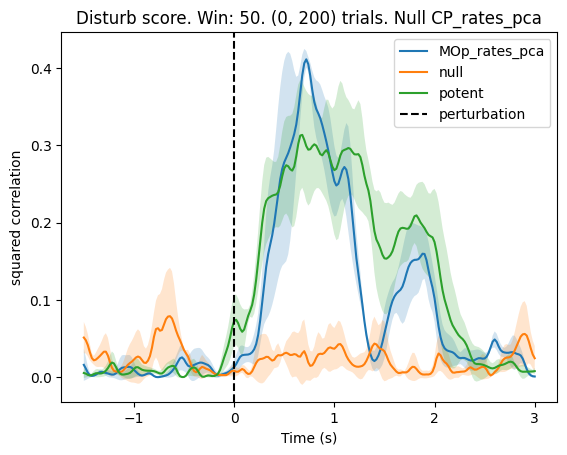

In [21]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=origin_signal)
vizutils.shaded_errorbar(ax, times-2, scores_null, label='null')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='potent')


# ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('squared correlation')
ax.set_title(f'Disturb score. Win: {window}. {idx_to_keep} trials. Null {target_signal}')
# ax.set_ylim(-0.1, 0.1)
ax.legend()

ax.legend()

## VAL null comm subspaces

In [178]:
idx_to_keep = 100
window = 50
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
origin_signal = 'VAL_rates_pca'
target_signal = 'MOp_rates_pca'

X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)

Dropping classes with count < 3: [0, 4]
Counts: {0: 2, 1: 17, 2: 16, 3: 14, 4: 2, 5: 14, 6: 10, 7: 3, 8: 7, 9: 4, 10: 7, 11: 4}


  0%|          | 0/452 [00:00<?, ?it/s]

100%|██████████| 452/452 [00:04<00:00, 105.98it/s]


(-1.0, 2.0)

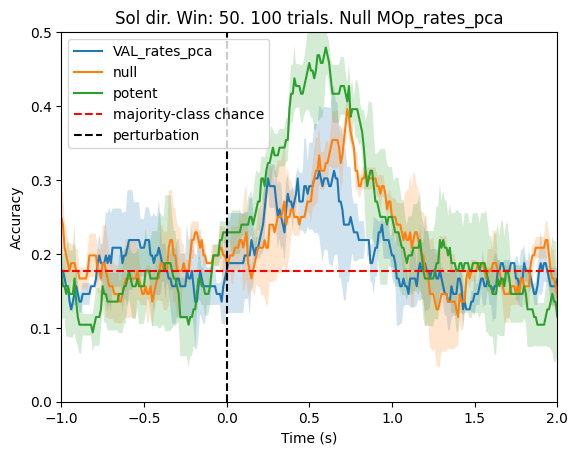

In [182]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=origin_signal)
vizutils.shaded_errorbar(ax, times-2, scores_null, label='null')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='potent')


ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Sol dir. Win: {window}. {idx_to_keep} trials. Null {target_signal}')

ax.legend()
ax.set_ylim(0, 0.5)
ax.set_xlim(-1, 2)


## CP null comm subspaces

In [ ]:
idx_to_keep = 100
window = 50
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
origin_signal = 'VAL_rates_pca'
target_signal = '_rates_pca'

X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)

KeyError: 'VAL_rates_pca_null_MOp_rates_pca'

(-1.0, 2.0)

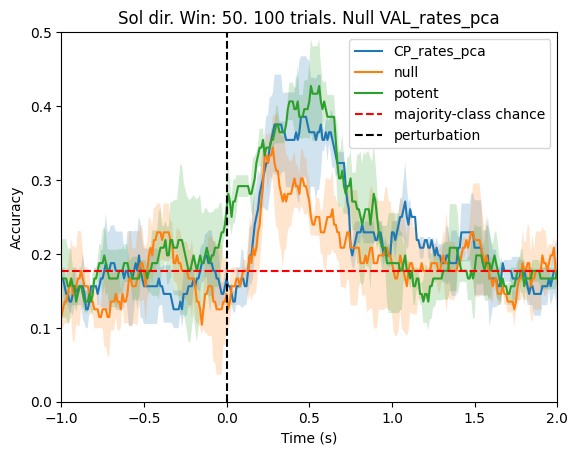

In [159]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=origin_signal)
vizutils.shaded_errorbar(ax, times-2, scores_null, label='null')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='potent')


ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Sol dir. Win: {window}. {idx_to_keep} trials. Null {target_signal}')

ax.legend()
ax.set_ylim(0, 0.5)
ax.set_xlim(-1, 2)


In [53]:
origin_signal ='CP_rates_pca'
target_signal = 'MOp_rates_pca'
scorer = make_scorer(r2_score)

idx_to_keep=(0, 200)
window = 50
idx = sorted(dstrb_idx[idx_to_keep[0]:idx_to_keep[1]])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
y = perturb_td_shuff_filt.disturb_sum.values
# y = np.concatenate(perturb_td_shuff_filt.disturb_score.values)


def opt_ridge_alpha(x_cv, y_cv):
    alphas = np.logspace(-6, 6, 50)
    ridge_cv = RidgeCV(alphas=alphas)
    ridge_cv.fit(x_cv, y_cv)
    return ridge_cv.alpha_

X_null = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
alpha = opt_ridge_alpha(
        X_null.reshape(X_null.shape[0], -1), 
        y
    )
print(alpha)
scores_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(alpha, solver='auto'),
    X_null,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

X_full = np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)
alpha = opt_ridge_alpha(
        X_full.reshape(X_null.shape[0], -1), 
        y
    )
print(alpha)
scores_full, times = decode.decoding_moving_window_no_time_concat(
    Ridge(alpha, solver='auto'),
    X_full,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

X_potent = np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)
alpha = opt_ridge_alpha(
        X_potent.reshape(X_null.shape[0], -1), 
        y
    )
print(alpha)
scores_potent, times = decode.decoding_moving_window_no_time_concat(
    Ridge(alpha, solver='auto'),
    X_potent,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

568986.6029018281


100%|██████████| 226/226 [00:02<00:00, 85.11it/s] 


59636.23316594637


100%|██████████| 226/226 [00:04<00:00, 53.54it/s]


184206.99693267164


100%|██████████| 226/226 [00:02<00:00, 78.99it/s]


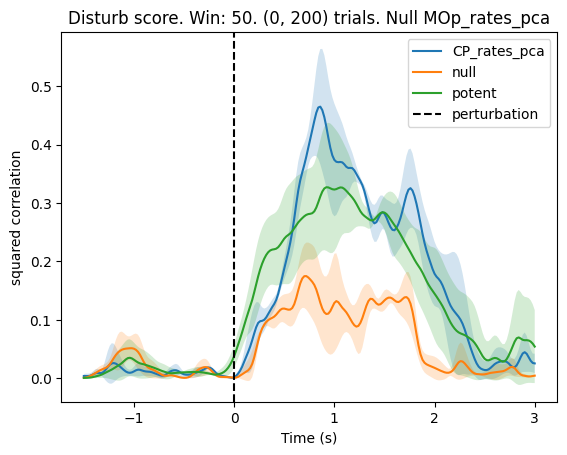

In [54]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=origin_signal)
vizutils.shaded_errorbar(ax, times-2, scores_null, label='null')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='potent')


# ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('squared correlation')
ax.set_title(f'Disturb score. Win: {window}. {idx_to_keep} trials. Null {target_signal}')
# ax.set_ylim(0, 0.5)
ax.legend()

ax.legend()